# 공정 조합 퍼널 · 로직과 시각화 점검

main 브랜치 웹 화면(`index.html`, `js/*.js`)의 분석 로직과 차트를 **Python 3.12**로 옮겨, 단계마다 중간 결과를 보면서 점검하는 노트북입니다.

- 난수(mulberry32)까지 같은 방식으로 옮겨서 **같은 시드면 웹과 같은 데이터, 같은 판정**이 나옵니다. 7-1에서 JS 결과와 직접 대조합니다.
- 통계 함수도 `js/stats.js`를 식 그대로 옮겨서 scipy 없이 numpy · pandas · matplotlib만 씁니다.
- 커널은 저장소 루트의 `.venv`(Python 3.12)를 고릅니다. 7-1의 JS 대조에는 Node.js가 필요합니다(없으면 건너뜀).

| 절 | 내용 | 원본 |
|---|---|---|
| 1 | 난수와 통계 함수 | `js/rng.js`, `js/stats.js` |
| 2 | mock 데이터 | `js/mock.js` |
| 3 | 오더별 유닛 ANOVA, 조합 생성, 조합별 지표 | `js/analysis.js` `analyze` |
| 4 | 기준선 3종과 판정 | `thresholds`, `classify`, `js/permWorker.js` |
| 5 | 조합 Funnel과 불량 조합 목록 | `js/app.js` |
| 6 | 선택한 조합의 상세 차트 | `js/detail.js` |
| 7 | 로직 점검: JS 대조, 여러 시드, 알려진 약점, good/bad 분석 방식 비교 | — |
| 8 | 한 차트 보기와 대표 불량 대상 (웹 반영 전 시험), 여러 스텝이 얽힐 때의 한계 | — |

## 0. 설정
아래 값만 바꿔서 위에서부터 다시 실행하면 됩니다. 기본값은 웹 화면의 기본값과 같습니다.

In [1]:
SEED = 20260928     # 데이터 시드 (웹 기본값)
MIN_N = 20          # 조합 최소 웨이퍼 수 (웹 슬라이더 기본값)
ENV = 'bonf'        # 판정 기준: 'bonf' 조합 수 보정 · 'perm' 순열 검정 · 'raw' 보정 없음 99.8%
N_PERM = 100        # 순열 검정 횟수 (웹과 같음)
STEP = None         # 특정 스텝만 볼 때 'STEP050'처럼 지정 (None이면 전체)
SHOW_REL = False    # funnel과 목록에 관련 조합(상속 · 하위 기인)도 표시
LOGX = True         # funnel 가로축 로그
SELECT = None       # 상세를 볼 조합: 불량 조합 목록의 순위(1, 2, …) 또는 조합 key. None이면 목록 위에서부터 MAX_DETAIL개
MAX_DETAIL = 4

PICK = None         # 8절에서 고를 점(조합 key). None이면 1위 대표 대상의 후보 중 기준선을 겨우 넘은 관련 조합
RANK = 'impact'     # 8절 '가장 불량한'의 기준: 'impact' 영향 · 'evidence' 증거 · 'severity' 심각도

CHECK_SEEDS = range(1, 21)   # 7-2 여러 시드 점검
LOT_SEEDS = range(1, 4)      # 7-3 랏 구조 실험
EXP_SEEDS = range(1, 11)     # 7-5 good/bad 분석 방식 비교

In [2]:
import itertools
import json
import math
import shutil
import subprocess
import sys
import time
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Patch, PathPatch, Rectangle
from matplotlib.path import Path as MplPath
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator, NullLocator

assert sys.version_info >= (3, 12), f'Python 3.12 이상이 필요합니다 (현재 {sys.version.split()[0]})'
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# 색: 회색 바탕에 상태색(불량 = 빨강) 하나, 선택 강조는 파랑
C = {
    'surface': '#fcfcfb', 'ink': '#0b0b0b', 'ink2': '#52514e', 'muted': '#898781',
    'grid': '#e1e0d9', 'axis': '#c3c2b7', 'band': '#ecebe6',
    'bad': '#d03b3b', 'accent': '#2a78d6',
    'low': '#2a78d6', 'mid': '#f0efec', 'high': '#e34948',   # 발산: 파랑 ↔ 회색 ↔ 빨강
}
_fonts = {f.name for f in mpl.font_manager.fontManager.ttflist}
KR_FONT = next((f for f in ('Apple SD Gothic Neo', 'AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Nanum Gothic', 'Noto Sans CJK KR', 'Noto Sans KR') if f in _fonts), 'DejaVu Sans')
plt.rcParams.update({
    'font.family': [KR_FONT, 'DejaVu Sans'], 'axes.unicode_minus': False, 'font.size': 10,
    'figure.dpi': 100, 'figure.facecolor': C['surface'], 'axes.facecolor': C['surface'], 'savefig.facecolor': C['surface'],
    'axes.edgecolor': C['axis'], 'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': C['grid'], 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'axes.titlecolor': C['ink'], 'axes.titlepad': 10,
    'axes.labelcolor': C['ink2'], 'axes.labelsize': 10,
    'xtick.color': C['axis'], 'ytick.color': C['axis'], 'xtick.labelcolor': C['ink2'], 'ytick.labelcolor': C['ink2'],
    'xtick.major.size': 0, 'ytick.major.size': 0, 'xtick.minor.size': 0, 'ytick.minor.size': 0,
    'legend.frameon': False, 'legend.fontsize': 9,
})
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:,.4g}'.format)


def mix(c1, c2, t):
    """sRGB에서 c1을 t, c2를 1−t 비율로 섞는다 (CSS color-mix와 같음)"""
    a, b = np.array(to_rgb(c1)), np.array(to_rgb(c2))
    return tuple(a * t + b * (1 - t))


def fmt_p(p):
    if p is None or not math.isfinite(p):
        return '–'
    return f'{p:.0e}' if p < 1e-4 else f'{p:.4f}'


def plain_log(axis):
    """로그축 눈금을 1 · 2 · 5 단위의 일반 숫자로"""
    axis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    axis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}' if v >= 1 else f'{v:g}'))
    axis.set_minor_locator(NullLocator())


print(f'Python {sys.version.split()[0]} · numpy {np.__version__} · pandas {pd.__version__} · matplotlib {mpl.__version__} · 글꼴 {KR_FONT}')

Python 3.12.13 · numpy 2.5.3 · pandas 3.0.6 · matplotlib 3.11.2 · 글꼴 Apple SD Gothic Neo


## 1. 난수와 통계 함수
`js/rng.js`와 `js/stats.js`를 식 그대로 옮깁니다.

- mulberry32는 JS의 32비트 정수 연산(`Math.imul`, `>>>`)을 마스크로 재현했습니다. 상태가 `seed + i·0x6D2B79F5`로만 바뀌므로, 난수를 많이 쓰는 곳은 numpy로 한꺼번에 계산합니다.
- 분포 함수(정규 · t · F)도 JS와 같은 근사식을 씁니다. 그래서 p-value까지 JS와 거의 같은 값이 나옵니다.

In [3]:
M32 = 0xFFFFFFFF
INC = 0x6D2B79F5
U64 = np.uint64


def _mulberry(a: int) -> float:
    """mulberry32 출력 하나. a는 INC를 더한 뒤의 상태"""
    t = ((a ^ (a >> 15)) * (a | 1)) & M32
    t = ((t + (((t ^ (t >> 7)) * (t | 61)) & M32)) & M32) ^ t
    return ((t ^ (t >> 14)) & M32) / 4294967296


def _mulberry_vec(a: np.ndarray) -> np.ndarray:
    t = ((a ^ (a >> U64(15))) * (a | U64(1))) & U64(M32)
    t = ((t + (((t ^ (t >> U64(7))) * (t | U64(61))) & U64(M32))) & U64(M32)) ^ t
    return ((t ^ (t >> U64(14))) & U64(M32)).astype(np.float64) / 4294967296


class Rng:
    """js/rng.js makeRng. 같은 시드면 JS와 같은 수열을 낸다."""

    def __init__(self, seed: int):
        self.seed = seed & M32
        self.i = 0                         # 지금까지 쓴 난수 개수
        self.spare: float | None = None    # 정규난수 짝

    def u(self) -> float:
        self.i += 1
        return _mulberry((self.seed + self.i * INC) & M32)

    def take(self, n: int) -> np.ndarray:
        """다음 n개를 한꺼번에 쓴다"""
        k = np.arange(self.i + 1, self.i + n + 1, dtype=np.uint64)
        self.i += n
        return _mulberry_vec((U64(self.seed) + k * U64(INC)) & U64(M32))

    def peek(self, n: int) -> np.ndarray:
        """다음 n개를 쓰지 않고 미리 본다"""
        v = self.take(n)
        self.i -= n
        return v

    def skip(self, n: int) -> None:
        self.i += n

    def normal(self) -> float:
        """Marsaglia polar. 한 번에 두 개를 만들어 하나는 다음 호출에 쓴다"""
        if self.spare is not None:
            s, self.spare = self.spare, None
            return s
        while True:
            a, b = self.u() * 2 - 1, self.u() * 2 - 1
            r = a * a + b * b
            if 0 < r < 1:
                break
        f = math.sqrt((-2 * math.log(r)) / r)
        self.spare = b * f
        return a * f

    def randint(self, lo: int, hi: int) -> int:
        """JS r.int(lo, hi): [lo, hi] 정수"""
        return lo + math.floor(self.u() * (hi - lo + 1))

    def pick(self, arr):
        return arr[math.floor(self.u() * len(arr))]

    def geometric(self, p: float) -> int:
        """성공확률 p인 기하분포의 실패 횟수 (0, 1, 2, … 상한 없음)"""
        return math.floor(math.log(1 - self.u()) / math.log(1 - p))

    def weighted(self, cum: np.ndarray) -> int:
        """누적 가중치 배열에서 인덱스 선택"""
        return int(np.searchsorted(cum, self.u() * cum[-1], side='left'))

    def shuffle(self, arr: list) -> list:
        for i in range(len(arr) - 1, 0, -1):
            j = math.floor(self.u() * (i + 1))
            arr[i], arr[j] = arr[j], arr[i]
        return arr

In [4]:
SQRT2 = math.sqrt(2)
_A = (-39.69683028665376, 220.9460984245205, -275.9285104469687, 138.357751867269, -30.66479806614716, 2.506628277459239)
_B = (-54.47609879822406, 161.5858368580409, -155.6989798598866, 66.80131188771972, -13.28068155288572)
_C = (-0.007784894002430293, -0.3223964580411365, -2.400758277161838, -2.549732539343734, 4.374664141464968, 2.938163982698783)
_D = (0.007784695709041462, 0.3224671290700398, 2.445134137142996, 3.754408661907416)
_LG = (76.18009172947146, -86.50532032941677, 24.01409824083091, -1.231739572450155, 0.1208650973866179e-2, -0.5395239384953e-5)


def erfc(x):
    """상보 오차함수 (Numerical Recipes erfcc, 상대오차 < 1.2e-7)"""
    x = np.asarray(x, dtype=float)
    z = np.abs(x)
    t = 1 / (1 + 0.5 * z)
    poly = 1.00002368 + t * (0.37409196 + t * (0.09678418 + t * (-0.18628806 + t * (0.27886807 + t * (-1.13520398 + t * (1.48851587 + t * (-0.82215223 + t * 0.17087277)))))))
    r = t * np.exp(-z * z - 1.26551223 + t * poly)
    return np.where(x >= 0, r, 2 - r)


def norm_cdf(z):
    return 0.5 * erfc(-np.asarray(z, dtype=float) / SQRT2)


def norm_sf(z):
    """상단 꼬리확률 P(Z > z)"""
    return 0.5 * erfc(np.asarray(z, dtype=float) / SQRT2)


def norm_inv(p: float) -> float:
    """표준정규 분위수 (Acklam + Halley 1회 보정)"""
    if p <= 0:
        return -math.inf
    if p >= 1:
        return math.inf
    pl = 0.02425
    if p < pl:
        q = math.sqrt(-2 * math.log(p))
        x = (((((_C[0] * q + _C[1]) * q + _C[2]) * q + _C[3]) * q + _C[4]) * q + _C[5]) / ((((_D[0] * q + _D[1]) * q + _D[2]) * q + _D[3]) * q + 1)
    elif p <= 1 - pl:
        q = p - 0.5
        r = q * q
        x = ((((((_A[0] * r + _A[1]) * r + _A[2]) * r + _A[3]) * r + _A[4]) * r + _A[5]) * q) / (((((_B[0] * r + _B[1]) * r + _B[2]) * r + _B[3]) * r + _B[4]) * r + 1)
    else:
        q = math.sqrt(-2 * math.log(1 - p))
        x = -(((((_C[0] * q + _C[1]) * q + _C[2]) * q + _C[3]) * q + _C[4]) * q + _C[5]) / ((((_D[0] * q + _D[1]) * q + _D[2]) * q + _D[3]) * q + 1)
    e = float(norm_cdf(x)) - p
    u = e * math.sqrt(2 * math.pi) * math.exp((x * x) / 2)
    return x - u / (1 + (x * u) / 2)


def lgamma(x):
    x = np.asarray(x, dtype=float)
    y = x.copy()
    tmp = x + 5.5 - (x + 0.5) * np.log(x + 5.5)
    ser = 1.000000000190015
    for g in _LG:
        y = y + 1
        ser = ser + g / y
    return -tmp + np.log((2.5066282746310005 * ser) / x)


def betacf(a, b, x):
    """불완전 베타의 연분수. 원소마다 수렴하면 멈춘다 (JS의 break와 같음)"""
    a, b, x = np.broadcast_arrays(*(np.asarray(v, dtype=float) for v in (a, b, x)))
    MAXIT, EPS, FPMIN = 300, 3e-14, 1e-300
    qab, qap, qam = a + b, a + 1, a - 1
    floor = lambda v: np.where(np.abs(v) < FPMIN, FPMIN, v)
    c = np.ones_like(x)
    d = 1 / floor(1 - (qab * x) / qap)
    h = d.copy()
    live = np.ones(x.shape, dtype=bool)
    with np.errstate(all='ignore'):
        for m in range(1, MAXIT + 1):
            m2 = 2 * m
            aa = (m * (b - m) * x) / ((qam + m2) * (a + m2))
            d1 = 1 / floor(1 + aa * d)
            c1 = floor(1 + aa / c)
            h1 = h * (d1 * c1)
            aa = (-(a + m) * (qab + m) * x) / ((a + m2) * (qap + m2))
            d1 = 1 / floor(1 + aa * d1)
            c1 = floor(1 + aa / c1)
            de = d1 * c1
            h1 = h1 * de
            c, d, h = np.where(live, c1, c), np.where(live, d1, d), np.where(live, h1, h)
            live &= ~(np.abs(de - 1) < EPS)
            if not live.any():
                break
    return h


def ibeta(x, a, b):
    """정규화 불완전 베타 I_x(a, b)"""
    x, a, b = np.broadcast_arrays(*(np.atleast_1d(np.asarray(v, dtype=float)) for v in (x, a, b)))
    out = np.where(x <= 0, 0.0, 1.0)
    mid = (x > 0) & (x < 1)
    if mid.any():
        xm, am, bm = x[mid], a[mid], b[mid]
        bt = np.exp(lgamma(am + bm) - lgamma(am) - lgamma(bm) + am * np.log(xm) + bm * np.log(1 - xm))
        front = xm < (am + 1) / (am + bm + 2)
        r = np.empty_like(xm)
        if front.any():
            r[front] = (bt[front] * betacf(am[front], bm[front], xm[front])) / am[front]
        back = ~front
        if back.any():
            r[back] = 1 - (bt[back] * betacf(bm[back], am[back], 1 - xm[back])) / bm[back]
        out[mid] = r
    return out


def f_sf(f, d1, d2):
    """P(F > f), F ~ F(d1, d2)"""
    f = np.atleast_1d(np.asarray(f, dtype=float))
    with np.errstate(all='ignore'):
        p = ibeta(d2 / (d2 + d1 * f), d2 / 2, d1 / 2)
    return np.where(f <= 0, 1.0, p)


def t_sf(t, df):
    """단측 P(T > t), T ~ t(df)"""
    t, df = np.atleast_1d(np.asarray(t, dtype=float)), np.atleast_1d(np.asarray(df, dtype=float))
    p = 0.5 * ibeta(df / (df + t * t), df / 2, 0.5)
    return np.where(t >= 0, p, 1 - p)


def var_of(n, s, ss):
    """요약통계 (n, 합, 제곱합) → 표본분산"""
    return max(0.0, (ss - (s * s) / n) / (n - 1)) if n > 1 else 0.0


def anova(n, s, ss):
    """one-way ANOVA. 입력은 그룹별 n · 합 · 제곱합 배열"""
    keep = n > 0
    n, s, ss = n[keep].tolist(), s[keep].tolist(), ss[keep].tolist()
    k, N_ = len(n), sum(n)
    if k < 2 or N_ - k < 1:
        return None
    grand = 0.0
    for v in s:
        grand += v
    grand /= N_
    ssb = ssw = 0.0
    for ni, si, ssi in zip(n, s, ss):
        m = si / ni
        ssb += ni * (m - grand) ** 2
        ssw += ssi - ni * m * m
    d1, d2 = k - 1, N_ - k
    F = ssb / d1 / (ssw / d2)
    return {'F': F, 'd1': d1, 'd2': d2, 'p': float(f_sf(F, d1, d2)[0])}


def welch(na, sa, ssa, nb, sb, ssb):
    """a가 b보다 큰지 단측 Welch t. 입력은 요약통계(n, 합, 제곱합) 배열"""
    na, sa, ssa, nb, sb, ssb = (np.atleast_1d(np.asarray(v, dtype=float)) for v in (na, sa, ssa, nb, sb, ssb))
    t, df, p = np.zeros_like(na), np.ones_like(na), np.ones_like(na)
    ok = (na >= 2) & (nb >= 2)
    with np.errstate(all='ignore'):
        va = np.maximum(0, (ssa - (sa * sa) / na) / (na - 1)) / na
        vb = np.maximum(0, (ssb - (sb * sb) / nb) / (nb - 1)) / nb
        se = np.sqrt(va + vb)
        ok &= se != 0
        t[ok] = (sa[ok] / na[ok] - sb[ok] / nb[ok]) / se[ok]
        df[ok] = (va[ok] + vb[ok]) ** 2 / ((va[ok] * va[ok]) / (na[ok] - 1) + (vb[ok] * vb[ok]) / (nb[ok] - 1))
    if ok.any():
        p[ok] = t_sf(t[ok], df[ok])
    return t, df, p


def bh_q(p):
    """Benjamini–Hochberg q-value"""
    p = np.asarray(p, dtype=float)
    order = np.argsort(p, kind='stable')
    ranked = (p[order] * len(p)) / (np.arange(len(p)) + 1)
    q = np.empty_like(p)
    q[order] = np.minimum.accumulate(np.minimum(ranked[::-1], 1.0))[::-1]
    return q


def quantile(v, p):
    """정렬된 배열의 선형 보간 분위수"""
    if not len(v):
        return math.nan
    h = (len(v) - 1) * p
    lo = math.floor(h)
    return float(v[lo] + (h - lo) * (v[min(lo + 1, len(v) - 1)] - v[lo]))


def norm_isf(p):
    """상단 꼬리확률 p → z (배열). 아주 작은 p도 정밀하도록 하단 꼬리 식에 p를 바로 넣는다 (7절 실험용)"""
    p = np.clip(np.atleast_1d(np.asarray(p, dtype=float)), 1e-300, 1 - 1e-16)
    x = np.empty_like(p)
    lo, hi = p < 0.02425, p > 1 - 0.02425
    mid = ~(lo | hi)
    q = np.sqrt(-2 * np.log(p[lo]))
    x[lo] = (((((_C[0] * q + _C[1]) * q + _C[2]) * q + _C[3]) * q + _C[4]) * q + _C[5]) / ((((_D[0] * q + _D[1]) * q + _D[2]) * q + _D[3]) * q + 1)
    q = p[mid] - 0.5
    r = q * q
    x[mid] = ((((((_A[0] * r + _A[1]) * r + _A[2]) * r + _A[3]) * r + _A[4]) * r + _A[5]) * q) / (((((_B[0] * r + _B[1]) * r + _B[2]) * r + _B[3]) * r + _B[4]) * r + 1)
    q = np.sqrt(-2 * np.log(1 - p[hi]))
    x[hi] = -(((((_C[0] * q + _C[1]) * q + _C[2]) * q + _C[3]) * q + _C[4]) * q + _C[5]) / ((((_D[0] * q + _D[1]) * q + _D[2]) * q + _D[3]) * q + 1)
    with np.errstate(all='ignore'):
        e = norm_cdf(x) - p
        u = e * math.sqrt(2 * math.pi) * np.exp((x * x) / 2)
        refined = x - u / (1 + (x * u) / 2)
    x = np.where(np.isfinite(refined) & (p > 1e-250), refined, x)
    return -x

옮긴 함수가 맞는지 닫힌 식이 있는 값으로 확인합니다.

In [5]:
checks = pd.DataFrame([
    ('norm_inv(0.975)', norm_inv(0.975), 1.959964),
    ('norm_sf(3.090232)', float(norm_sf(3.090232)[()]), 0.001),
    ('t_sf(2, df 2)', float(t_sf(2, 2)[0]), 0.5 * (1 - 2 / math.sqrt(6))),
    ('f_sf(3, 2, 20)', float(f_sf(3, 2, 20)[0]), (1 + 2 * 3 / 20) ** -10),
    ('이항 P(X ≥ 3), n 10, p 0.2', float(ibeta(0.2, 3, 8)[0]), 1 - sum(math.comb(10, i) * 0.2 ** i * 0.8 ** (10 - i) for i in range(3))),
], columns=['함수', '이 노트북', '닫힌 식'])
checks['상대오차'] = (checks['이 노트북'] / checks['닫힌 식'] - 1).abs()
checks

,함수,이 노트북,닫힌 식,상대오차
0,norm_inv(0.975),1.96,1.96,2.696e-08
1,norm_sf(3.090232),0.001,0.001,1.075e-06
2,"t_sf(2, df 2)",0.09175,0.09175,4.752e-14
3,"f_sf(3, 2, 20)",0.07254,0.07254,3.872e-13
4,"이항 P(X ≥ 3), n 10, p 0.2",0.3222,0.3222,7.983e-13


## 2. mock 데이터 (`js/mock.js`)
- 스텝 100개, 웨이퍼 5,000장(200랏 × 25장), 웨이퍼마다 불량률 Y 하나 (평균 2.0%, 표준편차 0.5)
- 스텝마다 오더 수 = 1 + 기하분포(p 0.3), 오더마다 유닛 1~14개, 스텝별 이력 결측 1.5%
- 함정 스텝 3개(오더 12~18개)와 진짜 불량 4건을 심습니다: 오더 2개 조합 2건(+0.25%p), 단일 유닛 1건(+0.15%p), 오더 3개 조합 1건(+0.45%p)
- 유닛은 웨이퍼마다 독립으로 배정되고, 랏 간 편차는 없습니다. 이 가정이 깨질 때는 7-3에서 봅니다.

In [6]:
MISSING = 0xFFFF
PROC = ['PHO', 'ETC', 'CVD', 'PVD', 'CMP', 'IMP', 'DIF', 'CLN', 'MET', 'RTP']
DEFAULTS = {
    'nSteps': 100, 'nLots': 200, 'waferPerLot': 25, 'mu': 2.0, 'sigma': 0.5, 'missingRate': 0.015,
    'seqGeomP': 0.3, 'nDecoy': 3, 'effects': {'pair': 0.25, 'single': 0.15, 'triple': 0.45},
}


def sample_unit_count(r: Rng) -> int:
    x = r.u()
    if x < 0.3:
        return 1
    if x < 0.7:
        return r.randint(2, 4)
    if x < 0.9:
        return r.randint(5, 9)
    return r.randint(10, 14)


def build_seq(r: Rng, proc: str, q: int, n_units: int) -> dict:
    base = r.randint(1, 60)
    units = [f'{proc}{base + j:02d}' for j in range(n_units)]
    cum, acc = [], 0.0
    for _ in range(n_units):            # 유닛별 배정 비율: 거의 균등, 0.7~1.3배로 흔듦
        acc += 0.7 + 0.6 * r.u()
        cum.append(acc)
    return {'name': f'O{q + 1}', 'units': units, 'cum': np.array(cum)}


def generate(seed: int = 20260928, **options) -> dict:
    cfg = {**DEFAULTS, **options, 'effects': {**DEFAULTS['effects'], **options.get('effects', {})}}
    r = Rng(seed)
    N = cfg['nLots'] * cfg['waferPerLot']

    # 특수 스텝 배정: 함정(decoy) + 주입 스텝 4개
    order = r.shuffle(list(range(cfg['nSteps'])))
    decoy = set(order[:cfg['nDecoy']])
    pair_a, pair_b, single, triple = order[cfg['nDecoy']:cfg['nDecoy'] + 4]

    steps, plan = [], {}
    for s in range(cfg['nSteps']):
        proc = r.pick(PROC)
        n_seq = 1 + r.geometric(cfg['seqGeomP'])
        if s in decoy:
            n_seq = r.randint(12, 18)
            counts = [r.randint(10, 14) if r.u() < 0.5 else sample_unit_count(r) for _ in range(n_seq)]
        else:
            if s in (pair_a, pair_b, single):
                n_seq = max(n_seq, 2)
            if s == triple:
                n_seq = max(n_seq, 3)
            counts = [sample_unit_count(r) for _ in range(n_seq)]

        # 주입 스텝은 탐지 가능한 구조로 보정
        idx = r.shuffle(list(range(n_seq)))
        if s in (pair_a, pair_b):
            counts[idx[0]] = r.randint(3, 5)
            counts[idx[1]] = r.randint(3, 5)
            plan[s] = idx[:2]
        elif s == single:
            counts[idx[0]] = r.randint(3, 5)
            counts[idx[1]] = max(2, min(counts[idx[1]], 4))
            plan[s] = idx[:1]
        elif s == triple:
            counts[idx[0]] = r.randint(3, 4)
            counts[idx[1]] = r.randint(3, 4)
            counts[idx[2]] = r.randint(2, 3)
            plan[s] = idx[:3]
        seqs = [build_seq(r, proc, q, c) for q, c in enumerate(counts)]
        steps.append({'index': s, 'name': f'STEP{s + 1:03d}', 'proc': proc, 'seqs': seqs, 'decoy': s in decoy})

    # 웨이퍼별 유닛 배정 assign[s][q, w] (결측 = MISSING).
    # JS는 웨이퍼마다 결측 판정 난수 1개 + (결측이 아니면) 오더 수만큼 난수를 쓰므로 같은 순서로 소비한다
    assign = []
    for st in steps:
        nq = len(st['seqs'])
        buf = r.peek(N * (1 + nq))
        first = buf.tolist()
        start = np.zeros(N, dtype=np.int64)
        miss = np.zeros(N, dtype=bool)
        pos = 0
        for w in range(N):
            if first[pos] < cfg['missingRate']:
                miss[w] = True
                pos += 1
            else:
                start[w] = pos + 1
                pos += 1 + nq
        r.skip(pos)
        arr = np.full((nq, N), MISSING, dtype=np.uint16)
        ok = ~miss
        for q, sq in enumerate(st['seqs']):
            arr[q, ok] = np.searchsorted(sq['cum'], buf[start[ok] + q] * sq['cum'][-1], side='left')
        assign.append(arr)

    # 주입 효과
    effects = []
    for typ, s in (('pair', pair_a), ('pair', pair_b), ('single', single), ('triple', triple)):
        items = [(q, r.randint(0, len(steps[s]['seqs'][q]['units']) - 1)) for q in plan[s]]
        effects.append({'type': typ, 'step': s, 'items': items, 'delta': cfg['effects'][typ]})

    # Y 생성 (효과는 웨이퍼마다 같은 순서로 더한다)
    y = np.array([cfg['mu'] + cfg['sigma'] * r.normal() for _ in range(N)])
    for e in effects:
        hit = np.all([assign[e['step']][q] == u for q, u in e['items']], axis=0)
        e['n'] = int(hit.sum())
        y[hit] += e['delta']
    return {'seed': seed, 'cfg': cfg, 'N': N, 'Y': np.maximum(0, y), 'steps': steps, 'assign': assign, 'effects': effects}

생성 0.1초 · 스텝 100개 · 오더 393개 · 유닛 1635개 · 웨이퍼 5,000장
Y 평균 2.114% · 표준편차 0.522 · 스텝별 이력 결측 평균 1.48%


,유형,스텝,공정,스텝 오더 수,경로,효과(%p),해당 웨이퍼
심어 둔 불량,,,,,,,
1,오더 2개 조합,STEP050,DIF,4,O3:DIF17 → O2:DIF30,0.25,415
2,오더 2개 조합,STEP056,DIF,4,O1:DIF58 → O3:DIF11,0.25,358
3,단일 유닛,STEP025,CLN,2,O1:CLN18,0.15,1826
4,오더 3개 조합,STEP013,IMP,8,O5:IMP02 → O4:IMP18 → O8:IMP11,0.45,146


,공정,오더 수,오더별 유닛 수
함정 스텝,,,
STEP002,PHO,15,4 14 10 4 1 3 2 11 1 14 10 11 2 2 13
STEP019,MET,15,4 2 11 14 10 10 3 2 1 10 2 12 12 11 4
STEP068,CVD,15,12 10 14 12 12 11 12 1 10 1 2 13 12 11 1


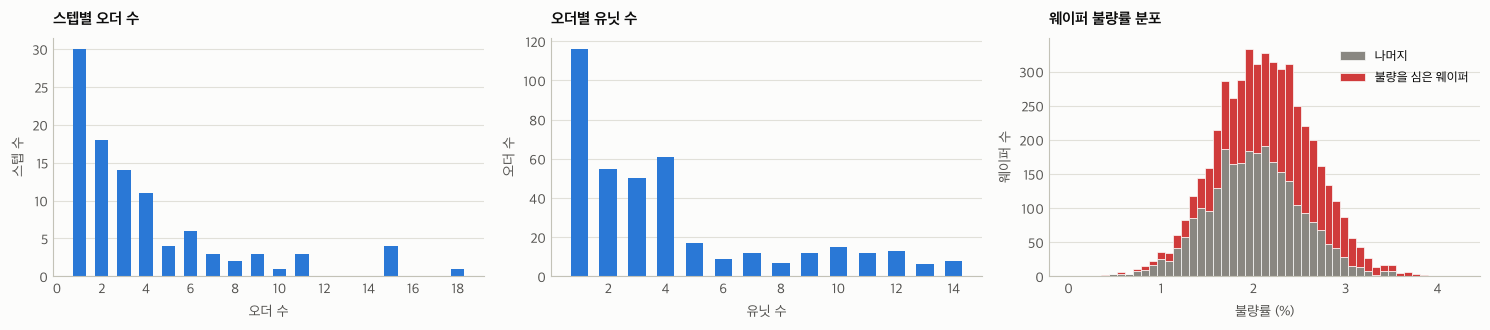

In [7]:
t0 = time.perf_counter()
data = generate(SEED)
steps, N, Y = data['steps'], data['N'], data['Y']
TYPE_LABEL = {'pair': '오더 2개 조합', 'single': '단일 유닛', 'triple': '오더 3개 조합'}


def path_label(st, items, sep=' → '):
    return sep.join(f"{st['seqs'][q]['name']}:{st['seqs'][q]['units'][u]}" for q, u in items)


n_orders = sum(len(s['seqs']) for s in steps)
n_units = sum(len(q['units']) for s in steps for q in s['seqs'])
print(f'생성 {time.perf_counter() - t0:.1f}초 · 스텝 {len(steps)}개 · 오더 {n_orders}개 · 유닛 {n_units}개 · 웨이퍼 {N:,}장')
print(f"Y 평균 {Y.mean():.3f}% · 표준편차 {Y.std(ddof=1):.3f} · 스텝별 이력 결측 평균 {np.mean([(a[0] == MISSING).mean() for a in data['assign']]):.2%}")
display(pd.DataFrame([{
    '유형': TYPE_LABEL[e['type']], '스텝': steps[e['step']]['name'], '공정': steps[e['step']]['proc'],
    '스텝 오더 수': len(steps[e['step']]['seqs']), '경로': path_label(steps[e['step']], e['items']),
    '효과(%p)': e['delta'], '해당 웨이퍼': e['n'],
} for e in data['effects']], index=pd.RangeIndex(1, 5, name='심어 둔 불량')))
display(pd.DataFrame([{
    '함정 스텝': s['name'], '공정': s['proc'], '오더 수': len(s['seqs']),
    '오더별 유닛 수': ' '.join(str(len(q['units'])) for q in s['seqs']),
} for s in steps if s['decoy']]).set_index('함정 스텝'))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
cnt = np.bincount([len(s['seqs']) for s in steps])
axes[0].bar(np.arange(1, len(cnt)), cnt[1:], width=0.6, color=C['accent'])
axes[0].set(title='스텝별 오더 수', xlabel='오더 수', ylabel='스텝 수')
cnt = np.bincount([len(q['units']) for s in steps for q in s['seqs']])
axes[1].bar(np.arange(1, len(cnt)), cnt[1:], width=0.6, color=C['accent'])
axes[1].set(title='오더별 유닛 수', xlabel='유닛 수', ylabel='오더 수')
hit_any = np.zeros(N, dtype=bool)
for e in data['effects']:
    hit_any |= np.all([data['assign'][e['step']][q] == u for q, u in e['items']], axis=0)
bins = np.linspace(0, Y.max(), 50)
axes[2].hist([Y[~hit_any], Y[hit_any]], bins=bins, stacked=True, color=[C['muted'], C['bad']],
             label=['나머지', '불량을 심은 웨이퍼'], edgecolor=C['surface'], linewidth=0.5)
axes[2].set(title='웨이퍼 불량률 분포', xlabel='불량률 (%)', ylabel='웨이퍼 수')
axes[2].legend()
for ax in axes:
    ax.grid(axis='x', visible=False)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 3. 조합 생성과 조합별 지표 (`analyze`)
1. **전체 평균 μ · 표준편차 σ**: 모든 스텝이 필수 공정이라 웨이퍼 집합이 같으므로, 모든 조합이 같은 μ, σ를 씁니다.
2. **오더별 유닛 ANOVA**: 한 오더 안에서 유닛끼리 평균이 다른지 봅니다.
3. **조합 생성**: 유닛이 2개 이상인 오더만 씁니다. 웨이퍼 `MIN_N`장 이상인 셀만 조합이 됩니다. 오더 1·2개는 전부 만들고, 오더 3개는 오더 하나를 뺀 부모 조합 중 하나라도 z 1.96을 넘을 때만 만듭니다(Apriori).
4. **탐색 공간**: 가지치기로 건너뛴 튜플의 셀까지 세서, 보정 기준의 분모로 씁니다.
5. **조합별 지표**:
   - z와 단측 p, BH q-value
   - 교호작용 잔차: 조합 평균 − (μ + 각 유닛 주효과의 합)
   - 부모 대비 리프트: Welch t로 조합과 '부모 − 조합' 웨이퍼를 비교 (판정에는 부모 중 가장 작은 t를 씀)
   - 경험적 베이즈 수축 평균

`z_method='binom'`은 7절 실험용 옵션입니다. Y가 0/1일 때 정확 이항검정으로 z를 계산하며, 기본값 `'normal'`이 main과 같습니다.

In [8]:
Z95, Z998 = 1.959964, 3.090232
LIFT_ALPHA, FWER_ALPHA = 0.001, 0.05


def combo_key(s, items):
    return f'{s}|' + '|'.join(f'{q}:{u}' for q, u in items)


def tuple_key(s, qs):
    return f'{s}|' + ','.join(map(str, qs))


def analyze(data, min_n=20, max_depth=3, full_depth=2, z_method='normal'):
    N, Y, steps, assign = data['N'], data['Y'], data['steps'], data['assign']
    tot = tss = 0.0
    for y in Y.tolist():                      # JS와 같은 순서로 더한다
        tot += y
        tss += y * y
    mu = tot / N
    sd = math.sqrt((tss - (tot * tot) / N) / (N - 1))
    Y2 = Y * Y

    if z_method == 'binom':                   # 0/1 Y: 정확 이항 꼬리확률 → z
        def z_vec(n, s):
            n, x = np.asarray(n, dtype=float), np.rint(np.asarray(s, dtype=float))
            p = np.where(x <= 0, 1.0, ibeta(np.full_like(n, mu), np.maximum(x, 1), n - x + 1))
            return np.minimum(norm_isf(p), 38.0)
    else:
        def z_vec(n, s):
            n = np.asarray(n, dtype=float)
            return (np.asarray(s, dtype=float) / n - mu) / (sd / np.sqrt(n))

    # ---- (스텝, 오더 튜플) 단위 셀 집계: 웨이퍼를 한 번 훑어 모든 유닛 조합 셀을 채운다
    groups = {}

    def cell_keys(s, qs):
        A = assign[s][list(qs)]
        dims = [len(steps[s]['seqs'][q]['units']) for q in qs]
        ok = np.all(A != MISSING, axis=0)
        key = np.zeros(N, dtype=np.int64)
        for i, d in enumerate(dims):
            key = key * d + A[i]
        return dims, ok, key

    def get_group(s, qs):
        ck = (s, tuple(qs))
        if (g := groups.get(ck)) is None:
            dims, ok, key = cell_keys(s, qs)
            size, k_ok = math.prod(dims), key[ok]
            g = {'qs': tuple(qs), 'dims': dims,
                 'n': np.bincount(k_ok, minlength=size),
                 'sum': np.bincount(k_ok, weights=Y[ok], minlength=size),
                 'ss': np.bincount(k_ok, weights=Y2[ok], minlength=size)}
            groups[ck] = g
        return g

    def count_cells(s, qs):
        """가지치기한 튜플도 탐색 공간에는 센다 (캐시 없이 n ≥ min_n 셀 수만)"""
        dims, ok, key = cell_keys(s, qs)
        return int((np.bincount(key[ok], minlength=math.prod(dims)) >= min_n).sum())

    def decode(g, key):
        units = []
        for d in reversed(g['dims']):
            units.append(key % d)
            key //= d
        return tuple((q, int(u)) for q, u in zip(g['qs'], reversed(units)))

    def stats_of(s, items):
        g = get_group(s, [q for q, _ in items])
        key = 0
        for (_, u), d in zip(items, g['dims']):
            key = key * d + u
        return int(g['n'][key]), float(g['sum'][key]), float(g['ss'][key])

    # ---- 1) 오더별 유닛 유의차
    seq_info = []
    for s, st in enumerate(steps):
        rows = []
        for q, sq in enumerate(st['seqs']):
            g = get_group(s, [q])
            units = [{'name': name, 'n': int(g['n'][u]),
                      'mean': g['sum'][u] / g['n'][u] if g['n'][u] else math.nan,
                      'sd': math.sqrt(var_of(int(g['n'][u]), g['sum'][u], g['ss'][u]))}
                     for u, name in enumerate(sq['units'])]
            testable = len(sq['units']) >= 2
            rows.append({'name': sq['name'], 'units': units, 'testable': testable,
                         'anova': anova(g['n'], g['sum'], g['ss']) if testable else None})
        seq_info.append(rows)

    # ---- 2) 조합 생성
    combos, by_key = [], {}
    flagged = set()                           # z > Z95 인 조합 key
    flagged_tuples = defaultdict(set)         # 깊이별 `s|q1,q2`

    def add(s, items, n, sm, ss, z):
        c = {'id': len(combos), 'key': combo_key(s, items), 'step': s, 'k': len(items), 'items': items,
             'n': int(n), 'sum': float(sm), 'ss': float(ss), 'mean': float(sm) / int(n), 'z': float(z)}
        combos.append(c)
        by_key[c['key']] = c
        if c['z'] > Z95:
            flagged.add(c['key'])
            flagged_tuples[c['k']].add(tuple_key(s, [q for q, _ in items]))

    multi = [[q for q, sq in enumerate(st['seqs']) if len(sq['units']) >= 2] for st in steps]
    search = [0] * (max_depth + 1)
    tuples_eval, tuples_pruned = [0] * (max_depth + 1), [0] * (max_depth + 1)
    for k in range(1, max_depth + 1):
        gated = k > full_depth                # 이 깊이부터는 부모 중 하나라도 이탈해야 확장
        cand = []
        for s in range(len(steps)):
            if len(multi[s]) < k:
                continue
            for qs in itertools.combinations(multi[s], k):     # JS kSubsets와 같은 순서
                if gated and not any(tuple_key(s, qs[:i] + qs[i + 1:]) in flagged_tuples[k - 1] for i in range(k)):
                    search[k] += count_cells(s, qs)
                    tuples_pruned[k] += 1
                    continue
                tuples_eval[k] += 1
                g = get_group(s, qs)
                big = np.flatnonzero(g['n'] >= min_n)
                search[k] += len(big)
                cand.append((s, g, big))
        # z는 깊이별로 한꺼번에 계산하고, JS와 같은 순서로 조합을 붙인다
        zs = z_vec(np.concatenate([g['n'][b] for _, g, b in cand]), np.concatenate([g['sum'][b] for _, g, b in cand])).tolist() if cand else []
        j = 0
        for s, g, big in cand:
            for key in big.tolist():
                z, j = zs[j], j + 1
                items = decode(g, key)
                if gated and not any(combo_key(s, items[:i] + items[i + 1:]) in flagged for i in range(k)):
                    continue
                add(s, items, g['n'][key], g['sum'][key], g['ss'][key], z)

    # ---- 3) 조합별 부가 지표
    for c in combos:
        c['children'], c['parents'] = [], []
        if c['k'] == 1:
            c['resid'] = c['mean'] - mu        # 주효과
        else:                                  # 교호작용 잔차
            c['resid'] = c['mean'] - (mu + sum(seq_info[c['step']][q]['units'][u]['mean'] - mu for q, u in c['items']))

    # 부모 대비 리프트: 조합 vs (부모 − 조합) Welch t, 단측. 모든 (조합, 부모) 쌍을 배열로 한꺼번에 계산
    pairs = []
    for c in combos:
        for drop in range(c['k'] if c['k'] >= 2 else 0):
            p_items = c['items'][:drop] + c['items'][drop + 1:]
            pairs.append((c, p_items, *stats_of(c['step'], p_items)))
    if pairs:
        cn = np.array([p[0]['n'] for p in pairs], dtype=float)
        cs = np.array([p[0]['sum'] for p in pairs])
        css = np.array([p[0]['ss'] for p in pairs])
        pn = np.array([p[2] for p in pairs], dtype=float)
        ps = np.array([p[3] for p in pairs])
        pss = np.array([p[4] for p in pairs])
        rn, rs, rss = pn - cn, ps - cs, pss - css
        t, _, pv = welch(cn, cs, css, rn, rs, rss)
        with np.errstate(all='ignore'):
            rmean = np.where(rn > 0, rs / rn, np.nan)
        for (c, p_items, n_, s_, _), rn_, rm_, t_, p_ in zip(pairs, rn.tolist(), rmean.tolist(), t.tolist(), pv.tolist()):
            c['parents'].append({'key': combo_key(c['step'], p_items), 'items': p_items, 'n': n_, 'mean': s_ / n_,
                                 'rest_n': int(rn_), 'rest_mean': rm_, 't': t_, 'p': p_})
    for c in combos:
        if c['k'] >= 2:
            c['lift_p'] = max(0.0, *(pr['p'] for pr in c['parents']))
            c['lift_t'] = min(pr['t'] for pr in c['parents'])      # 판정에 쓰는 값 (JS liftT)
            diffs = [c['mean'] - pr['rest_mean'] for pr in c['parents']]
            c['lift'] = math.nan if any(math.isnan(d) for d in diffs) else min(diffs)
        else:
            c['lift_p'] = c['lift_t'] = c['lift'] = None
    for c in combos:
        for pr in c['parents']:
            if (P := by_key.get(pr['key'])) is not None:
                P['children'].append(c['id'])

    p_all = norm_sf(np.array([c['z'] for c in combos]))
    for c, p_, q_ in zip(combos, p_all.tolist(), bh_q(p_all).tolist()):
        c['p'], c['q'] = p_, q_

    # ---- 4) 경험적 베이즈 수축: k=1(선택 편향 없는 전수 집합)에서 조합 간 분산 τ² 추정
    d1 = [c for c in combos if c['k'] == 1]
    vbar = vm = 0.0
    for c in d1:
        vbar += (sd * sd) / c['n']
    for c in d1:
        vm += (c['mean'] - mu) ** 2
    vbar, vm = vbar / len(d1), vm / len(d1)
    tau2 = max(vm - vbar, 1e-12)
    kappa_raw = (sd * sd) / tau2
    kappa = min(max(kappa_raw, 5), 300)       # τ²≈0이면 κ가 발산하므로 상한 300
    for c in combos:
        c['shrunk'] = (c['n'] * c['mean'] + kappa * mu) / (c['n'] + kappa)

    depth_count = [0] * (max_depth + 1)
    for c in combos:
        depth_count[c['k']] += 1
    tuples_eval[1] = sum(len(m) for m in multi)
    return {
        'mu': mu, 'sd': sd, 'N': N, 'min_n': min_n, 'max_depth': max_depth, 'full_depth': full_depth, 'z_method': z_method,
        'z_one': lambda n, s: float(z_vec(np.array([n]), np.array([s]))[0]),
        'kappa': kappa, 'kappa_raw': kappa_raw, 'tau2': tau2, 'vm': vm, 'vbar': vbar,
        'seq_info': seq_info, 'combos': combos, 'by_key': by_key, 'depth_count': depth_count, 'search_space': search,
        'tuples_eval': tuples_eval, 'tuples_pruned': tuples_pruned,
        'raw_over': sum(c['z'] > Z998 for c in combos),
    }

In [9]:
t0 = time.perf_counter()
res = analyze(data, min_n=MIN_N)
print(f"분석 {time.perf_counter() - t0:.1f}초 · μ {res['mu']:.4f}% · σ {res['sd']:.4f} · 조합 {len(res['combos']):,}개")
display(pd.DataFrame({
    '평가한 조합': res['depth_count'][1:],
    '탐색 공간(보정 분모)': res['search_space'][1:],
    '평가한 오더 튜플': res['tuples_eval'][1:],
    '가지치기한 오더 튜플': res['tuples_pruned'][1:],
}, index=pd.Index([1, 2, 3], name='오더 수')))

inj = {(e['step'], q): TYPE_LABEL[e['type']] for e in data['effects'] for q, _ in e['items']}
an = pd.DataFrame([{
    '스텝': st['name'], '오더': info['name'], '유닛 수': len(info['units']), 'F': info['anova']['F'], 'p': info['anova']['p'],
    '심어 둔 불량': inj.get((s, q), ''),
} for s, st in enumerate(steps) for q, info in enumerate(res['seq_info'][s]) if info['anova']]).sort_values('p')
print(f"유닛 2개 이상인 오더 {len(an)}개 중 ANOVA p < 0.001: {(an['p'] < 0.001).sum()}개 (위에서 8개)")
display(an.head(8).reset_index(drop=True))

분석 1.0초 · μ 2.1141% · σ 0.5220 · 조합 37,040개


,평가한 조합,탐색 공간(보정 분모),평가한 오더 튜플,가지치기한 오더 튜플
오더 수,,,,
1,1519,1519,277,0
2,28384,28384,732,0
3,7137,116845,1570,374


유닛 2개 이상인 오더 277개 중 ANOVA p < 0.001: 7개 (위에서 8개)


,스텝,오더,유닛 수,F,p,심어 둔 불량
0,STEP025,O1,3,63.32,7.047e-28,단일 유닛
1,STEP056,O3,4,13.09,1.641e-08,오더 2개 조합
2,STEP050,O3,3,11.98,6.436e-06,오더 2개 조합
3,STEP013,O8,2,17.34,3.172e-05,오더 3개 조합
4,STEP013,O4,4,6.944,0.0001164,오더 3개 조합
5,STEP050,O2,4,5.846,0.0005554,오더 2개 조합
6,STEP013,O5,4,5.819,0.0005773,오더 3개 조합
7,STEP026,O1,4,3.67,0.01173,


**z 분포 점검**: 불량이 없는 조합의 z는 표준정규를 따라야 합니다. 오더 1·2개는 전수 평가라 곡선에 붙고, 오른쪽 끝의 몇 점이 심어 둔 불량입니다. 오더 3개는 부모가 z 1.96을 넘은 경우만 확장하므로 오른쪽으로 치우친 것이 정상입니다.

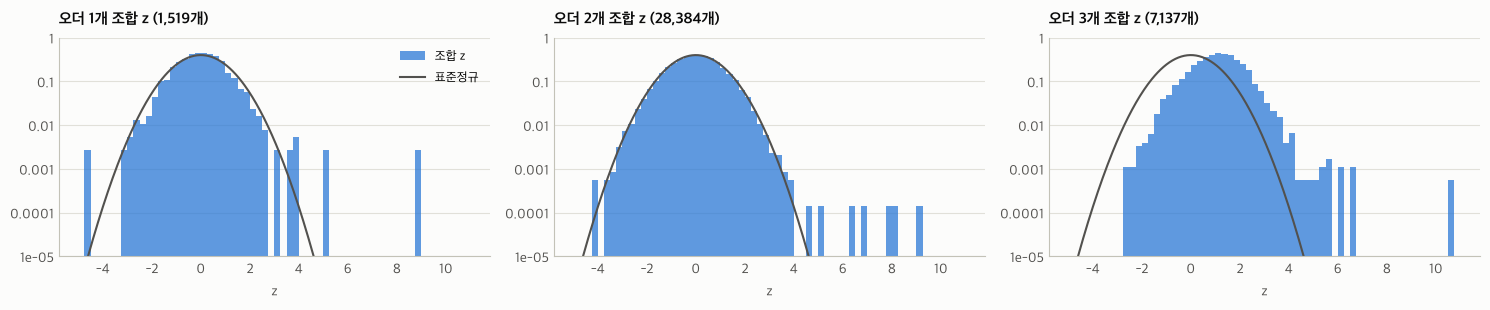

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
xs = np.linspace(-5, 11, 400)
for ax, k in zip(axes, (1, 2, 3)):
    z = np.array([c['z'] for c in res['combos'] if c['k'] == k])
    ax.hist(z, bins=np.arange(-5, 11.25, 0.25), density=True, color=C['accent'], alpha=0.75, label='조합 z')
    ax.plot(xs, np.exp(-xs ** 2 / 2) / math.sqrt(2 * math.pi), color=C['ink2'], lw=1.5, label='표준정규')
    ax.set(title=f'오더 {k}개 조합 z ({len(z):,}개)', xlabel='z', yscale='log', ylim=(1e-5, 1))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.grid(axis='x', visible=False)
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

## 4. 기준선과 판정 (`thresholds`, `classify`, `permWorker.js`)
**기준선 z (오더 개수별)**
- **조합 수 보정**: 탐색 공간 크기로 Bonferroni 보정 (`1 − 0.05 / 탐색 공간`의 정규 분위수)
- **순열 검정**: Y를 웨이퍼끼리 섞어서 '불량이 전혀 없을 때'의 최대 z 분포를 만들고, 그 95% 분위수를 씁니다(Westfall–Young max-T). 웹과 같은 난수로 섞습니다.
- **보정 없음**: z 3.09 (단측 0.1%)

**판정**
- 기준을 넘지 못하면 정상(z 1.96 초과는 경고)
- 기준을 넘은 오더 1개 조합은 불량
- 기준을 넘은 오더 2개 이상 조합은 부모 대비 Welch t(부모 중 가장 작은 값)도 같은 기준 z를 넘으면 불량, 아니면 관련 조합·상속. 이전 규칙(리프트 p < 0.001)과의 비교는 7-3에 있습니다.
- 불량 중에서, 오더를 더 붙인 불량 조합의 웨이퍼를 빼면 기준 안으로 들어오는 조합은 관련 조합·하위 기인

In [11]:
STATUS_LABEL = {'bad': '불량', 'inherited': '관련 조합 · 상속', 'explained': '관련 조합 · 하위 기인',
                'warn': '정상 범위', 'normal': '정상 범위', 'missing': '조합 없음'}
ENV_LABEL = {'bonf': '조합 수 보정', 'perm': '순열 검정', 'raw': '보정 없음 99.8%'}


def thresholds(res, method='bonf', perm_z=None):
    z = [0.0]
    for k in range(1, res['max_depth'] + 1):
        if method == 'raw':
            z.append(Z998)
        elif method == 'perm' and perm_z and perm_z[k]:
            z.append(perm_z[k])
        else:
            ss = res['search_space'][k]
            z.append(norm_inv(1 - FWER_ALPHA / ss) if ss else Z998)
    return z


def classify(res, zk, lift_rule='z'):
    """lift_rule 'z'가 현재 main: 부모 대비 Welch t도 기준 z를 넘어야 불량. 'p'는 이전 규칙(리프트 p < 0.001), 7-3 비교용"""
    combos, z_one = res['combos'], res['z_one']
    for c in combos:
        c['over'] = c['z'] > zk[c['k']]
        c['explained_by'] = None
        if not c['over']:
            c['status'] = 'warn' if c['z'] > Z95 else 'normal'
        elif c['k'] == 1:
            c['status'] = 'bad'
        else:
            lifted = c['lift_p'] < LIFT_ALPHA if lift_rule == 'p' else c['lift_t'] > zk[c['k']]
            c['status'] = 'bad' if lifted else 'inherited'
    # 이탈의 원인이 더 깊은 조합에 있으면: 그 조합을 뺀 나머지가 기준 안이면 '하위 기인'
    for k in range(res['max_depth'] - 1, 0, -1):
        for c in combos:
            if c['k'] != k or c['status'] != 'bad':
                continue
            for cid in c['children']:
                ch = combos[cid]
                if ch['status'] not in ('bad', 'explained'):
                    continue
                rn = c['n'] - ch['n']
                if rn < 2:
                    continue
                if z_one(rn, c['sum'] - ch['sum']) <= zk[k]:
                    c['status'], c['explained_by'] = 'explained', ch['id']
                    break
    count = lambda st: sum(c['status'] == st for c in combos)
    return {'over': sum(c['over'] for c in combos), 'bad': count('bad'), 'inherited': count('inherited'),
            'explained': count('explained'), 'warn': count('warn')}


def build_members(data, res):
    """조합별 웨이퍼 인덱스(오름차순). 같은 (스텝, 오더 튜플)끼리 묶어 한 번에 계산"""
    by_tuple = defaultdict(list)
    for c in res['combos']:
        by_tuple[(c['step'], tuple(q for q, _ in c['items']))].append(c)
    members = [None] * len(res['combos'])
    for (s, qs), cs in by_tuple.items():
        A = data['assign'][s][list(qs)]
        dims = [len(data['steps'][s]['seqs'][q]['units']) for q in qs]
        ok = np.all(A != MISSING, axis=0)
        key = np.zeros(data['N'], dtype=np.int64)
        for i, d in enumerate(dims):
            key = key * d + A[i]
        w = np.flatnonzero(ok)
        order = np.argsort(key[ok], kind='stable')
        ks, ws = key[ok][order], w[order]
        for c in cs:
            ck = 0
            for (_, u), d in zip(c['items'], dims):
                ck = ck * d + u
            members[c['id']] = ws[np.searchsorted(ks, ck, 'left'):np.searchsorted(ks, ck, 'right')]
    return members


def perm_envelope(data, res, n_perm=100, alpha=FWER_ALPHA, seed=SEED):
    """permWorker.js: Y를 웨이퍼끼리 섞어 깊이별 최대 z의 (1−α) 분위수. 후보 조합은 원 데이터 기준으로 고정"""
    members = build_members(data, res)
    lens = np.array([len(m) for m in members])
    offsets = np.concatenate([[0], np.cumsum(lens)[:-1]])
    flat = np.concatenate(members)
    depth = np.array([c['k'] for c in res['combos']])
    masks = {k: depth == k for k in range(1, res['max_depth'] + 1)}
    Yl = data['Y'].tolist()
    n = len(Yl)
    tot = tss = 0.0
    for y in Yl:
        tot += y
        tss += y * y
    mu = tot / n
    sd = math.sqrt((tss - (tot * tot) / n) / (n - 1))
    inv_se = np.sqrt(lens) / sd
    r = Rng((seed ^ 0x9E3779B9) & M32)
    perm = Yl[:]
    max_z = {k: [] for k in masks}
    for _ in range(n_perm):
        us = r.take(n - 1).tolist()          # Fisher–Yates: i = n−1 … 1 순서로 하나씩 쓴다
        for j_, i in enumerate(range(n - 1, 0, -1)):
            j = int(us[j_] * (i + 1))
            perm[i], perm[j] = perm[j], perm[i]
        z = (np.add.reduceat(np.array(perm)[flat], offsets) / lens - mu) * inv_se
        for k, m in masks.items():
            if m.any():
                max_z[k].append(z[m].max())
    out = [0.0]
    for k in masks:
        arr = np.sort(max_z[k])
        out.append(quantile(arr, 1 - alpha) if len(arr) else None)
    return out


def truth_check(data, res):
    """심어 둔 불량과 대조"""
    out = []
    for e in data['effects']:
        c = res['by_key'].get(combo_key(e['step'], tuple(sorted(e['items']))))
        out.append({'effect': e, 'combo': c, 'status': c['status'] if c else 'missing'})
    return out

In [12]:
t0 = time.perf_counter()
perm_z = perm_envelope(data, res, n_perm=N_PERM, seed=SEED)
print(f'순열 검정 {N_PERM}회 {time.perf_counter() - t0:.1f}초')
zks = {env: thresholds(res, env, perm_z) for env in ENV_LABEL}
display(pd.DataFrame({ENV_LABEL[e]: zks[e][1:] for e in ENV_LABEL}, index=pd.Index([1, 2, 3], name='오더 수')).rename_axis(columns='기준 z'))

rows = []
for env in ENV_LABEL:
    sm = classify(res, zks[env])
    hit = sum(t['status'] == 'bad' for t in truth_check(data, res))
    rows.append({'기준': ENV_LABEL[env], '보정 후 이탈': sm['over'], '불량': sm['bad'], '관련 · 상속': sm['inherited'],
                 '관련 · 하위 기인': sm['explained'], '심어 둔 불량 탐지': f'{hit}/4'})
display(pd.DataFrame(rows).set_index('기준'))

zk = zks[ENV]
summary = classify(res, zk)
print(f"[{ENV_LABEL[ENV]}] 조합 {len(res['combos']):,} › 99.8% 이탈 {res['raw_over']} › 보정 후 이탈 {summary['over']} › 불량 {summary['bad']}")

순열 검정 100회 1.3초


기준 z,조합 수 보정,순열 검정,보정 없음 99.8%
오더 수,,,
1,3.991,3.7,3.09
2,4.638,4.626,3.09
3,4.922,4.329,3.09


,보정 후 이탈,불량,관련 · 상속,관련 · 하위 기인,심어 둔 불량 탐지
기준,,,,,
조합 수 보정,19,4,12,3,4/4
순열 검정,23,4,14,5,4/4
보정 없음 99.8%,183,26,149,8,4/4


[조합 수 보정] 조합 37,040 › 99.8% 이탈 183 › 보정 후 이탈 19 › 불량 4


**판정 불변식 점검**: 판정 규칙이 코드에서 그대로 지켜지는지 전체 조합에 대해 확인합니다.

In [13]:
C_ = res['combos']
inv = {
    '불량은 모두 기준 z를 넘음': all(c['z'] > zk[c['k']] for c in C_ if c['status'] == 'bad'),
    '오더 2개 이상 불량은 부모 대비 t > 기준 z': all(c['lift_t'] > zk[c['k']] for c in C_ if c['status'] == 'bad' and c['k'] >= 2),
    '상속은 기준을 넘고 부모 대비 t ≤ 기준 z': all(c['over'] and c['lift_t'] <= zk[c['k']] for c in C_ if c['status'] == 'inherited'),
    '하위 기인은 원인 조합이 불량(또는 하위 기인)이고 부분집합': all(
        C_[c['explained_by']]['status'] in ('bad', 'explained') and set(c['items']) < set(C_[c['explained_by']]['items'])
        for c in C_ if c['status'] == 'explained'),
    '오더 3개 조합은 부모 중 하나가 z 1.96 초과': all(
        any(res['by_key'][pr['key']]['z'] > Z95 for pr in c['parents'] if pr['key'] in res['by_key']) for c in C_ if c['k'] == 3),
    '탐색 공간 ≥ 평가한 조합': all(res['search_space'][k] >= res['depth_count'][k] for k in (1, 2, 3)),
}
display(pd.DataFrame({'결과': ['✓' if v else '✗' for v in inv.values()]}, index=pd.Index(inv, name='불변식')))

display(pd.DataFrame([{
    '유형': TYPE_LABEL[t['effect']['type']], '스텝': steps[t['effect']['step']]['name'],
    '경로': path_label(steps[t['effect']['step']], sorted(t['effect']['items'])),
    '웨이퍼': t['combo']['n'] if t['combo'] else None, 'z': t['combo']['z'] if t['combo'] else None,
    '판정': STATUS_LABEL[t['status']],
} for t in truth_check(data, res)], index=pd.RangeIndex(1, 5, name='심어 둔 불량')))

,결과
불변식,
불량은 모두 기준 z를 넘음,✓
오더 2개 이상 불량은 부모 대비 t > 기준 z,✓
상속은 기준을 넘고 부모 대비 t ≤ 기준 z,✓
하위 기인은 원인 조합이 불량(또는 하위 기인)이고 부분집합,✓
오더 3개 조합은 부모 중 하나가 z 1.96 초과,✓
탐색 공간 ≥ 평가한 조합,✓


,유형,스텝,경로,웨이퍼,z,판정
심어 둔 불량,,,,,,
1,오더 2개 조합,STEP050,O2:DIF30 → O3:DIF17,415,9.034,불량
2,오더 2개 조합,STEP056,O1:DIF58 → O3:DIF11,358,8.085,불량
3,단일 유닛,STEP025,O1:CLN18,1826,8.83,불량
4,오더 3개 조합,STEP013,O4:IMP18 → O5:IMP02 → O8:IMP11,146,10.55,불량


## 5. 조합 Funnel (`app.js`)
가로축은 조합의 웨이퍼 수, 세로축은 평균 불량률입니다. 회색 띠가 우연 범위(μ ± z_k·σ/√n)이고, 띠 위로 벗어나 판정을 통과한 조합만 빨간 점(불량)으로 남습니다. 웹의 탭(오더 1/2/3개)을 한 줄에 나란히 그립니다.

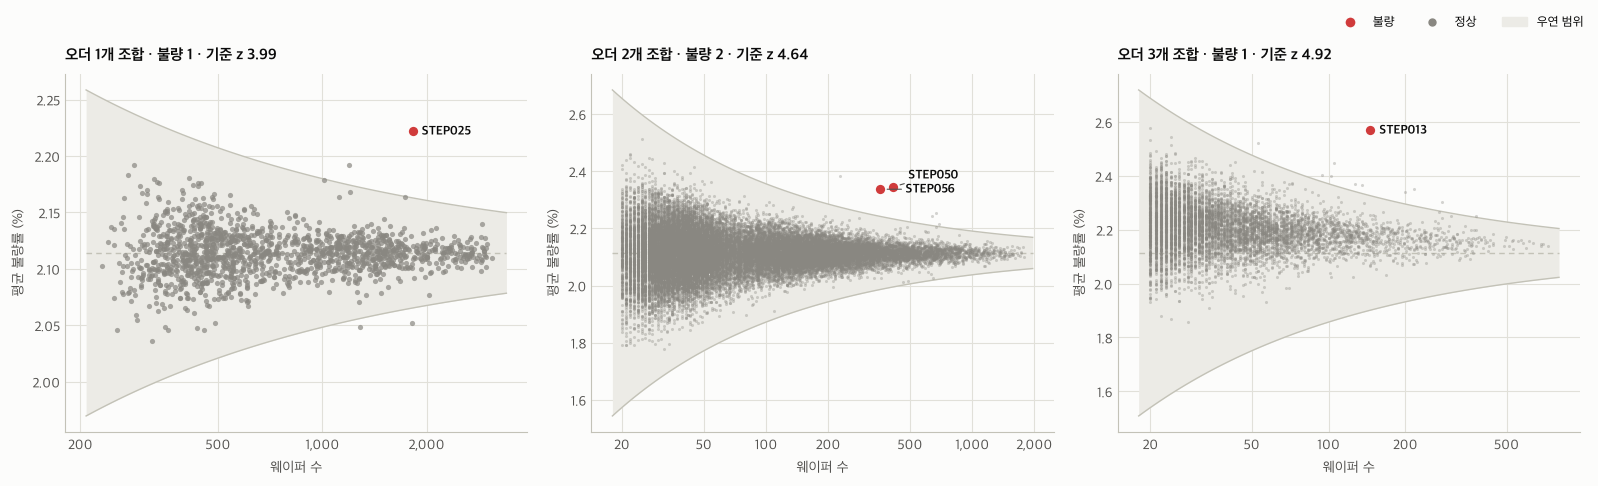

In [14]:
Y_LABEL = {'mean': '평균 불량률 (%)', 'shrunk': '수축 평균 (%)', 'resid': '교호작용 잔차 (%p)', 'z': 'z-score'}
in_scope = lambda c: STEP is None or steps[c['step']]['name'] == STEP


def y_of(c, ymode):
    return c[{'mean': 'mean', 'shrunk': 'shrunk', 'resid': 'resid', 'z': 'z'}[ymode]]


def env_at(n, z, ymode):
    """우연 범위의 중심과 반폭"""
    n = np.asarray(n, dtype=float)
    se = res['sd'] / np.sqrt(n)
    match ymode:
        case 'shrunk':
            return np.full_like(n, res['mu']), (n / (n + res['kappa'])) * z * se
        case 'resid':
            return np.zeros_like(n), z * se
        case 'z':
            return np.zeros_like(n), np.full_like(n, z)
        case _:
            return np.full_like(n, res['mu']), z * se


def style_logx(ax):
    ax.set_xscale('log')
    plain_log(ax.xaxis)


def plot_funnel(ax, k, ymode='mean', mark=None):
    vis = [c for c in res['combos'] if c['k'] == k and in_scope(c)]
    bad = [c for c in vis if c['status'] == 'bad']
    rel = [c for c in vis if c['status'] != 'bad' and c['over'] and SHOW_REL]
    normal = [c for c in vis if c['status'] != 'bad' and not (c['over'] and SHOW_REL)]
    ns = [c['n'] for c in vis] or [MIN_N, 5000]
    lo, hi = max(2, min(ns) * 0.9), max(ns) * 1.1
    grid = lo * (hi / lo) ** (np.arange(80) / 79)
    center, half = env_at(grid, zk[k], ymode)
    ax.fill_between(grid, center - half, center + half, color=C['band'], lw=0, zorder=1)
    for sign in (1, -1):
        ax.plot(grid, center + sign * half, color=C['axis'], lw=1, zorder=2)
    ax.plot([lo, hi], [center[0]] * 2, color=C['axis'], lw=1, ls=(0, (4, 3)), zorder=2)
    if normal:
        ax.scatter([c['n'] for c in normal], [y_of(c, ymode) for c in normal], s=14 if k == 1 else 5,
                   color=C['muted'], alpha=0.7 if k == 1 else 0.35, lw=0, zorder=3)
    if rel:
        ax.scatter([c['n'] for c in rel], [y_of(c, ymode) for c in rel], s=42, facecolors='none',
                   edgecolors=C['bad'], lw=1.2, alpha=0.85, zorder=4)
    if bad:
        ax.scatter([c['n'] for c in bad], [y_of(c, ymode) for c in bad], s=72, color=C['bad'],
                   edgecolors=C['surface'], lw=1.8, zorder=5)
    if mark is not None and mark['k'] == k:
        ax.scatter([mark['n']], [y_of(mark, ymode)], s=320, facecolors='none', edgecolors=C['accent'], lw=2.2, zorder=6)
    ax.set_title(f'오더 {k}개 조합 · 불량 {len(bad)} · 기준 z {zk[k]:.2f}')
    ax.set_xlabel('웨이퍼 수')
    ax.set_ylabel(Y_LABEL[ymode])
    if LOGX:
        style_logx(ax)
    label_points(ax, [(c['n'], y_of(c, ymode), steps[c['step']]['name']) for c in bad])


def label_points(ax, pts, gap=14):
    """불량 점 오른쪽에 스텝 이름. 점이 몰려 있으면 라벨을 무리의 오른쪽 바깥에 쌓고 가는 선으로 점과 잇는다"""
    if not pts:
        return
    ax.autoscale_view()
    disp = ax.transData.transform([(x, y) for x, y, _ in pts])
    placed = []
    for i in np.argsort(disp[:, 1]):
        x0, y0 = disp[i]
        near = [j for j in range(len(pts)) if abs(disp[j][0] - x0) < 70 and abs(disp[j][1] - y0) < 20]
        lx, ly = max(disp[j][0] for j in near) + 9, y0
        for px, py in sorted(placed, key=lambda p: p[1]):
            if abs(lx - px) < 70 and abs(ly - py) < gap:
                ly = py + gap
        placed.append((lx, ly))
        x, y, text = pts[i]
        moved = len(near) > 1 or ly != y0
        ax.annotate(text, (x, y), xytext=(lx - x0 + (6 if moved else 0), ly - y0), textcoords='offset pixels', va='center',
                    fontsize=9, fontweight='bold', color=C['ink'], zorder=6,
                    arrowprops={'arrowstyle': '-', 'color': C['ink2'], 'lw': 0.8, 'shrinkA': 1, 'shrinkB': 5} if moved else None)


def funnel_legend(fig):
    handles = [Line2D([], [], marker='o', ls='', color=C['bad'], mec=C['surface'], ms=8, label='불량')]
    if SHOW_REL:
        handles.append(Line2D([], [], marker='o', ls='', mfc='none', mec=C['bad'], ms=7, label='관련 조합'))
    handles += [Line2D([], [], marker='o', ls='', color=C['muted'], ms=5, label='정상'), Patch(color=C['band'], label='우연 범위')]
    fig.legend(handles=handles, loc='upper right', ncol=len(handles), bbox_to_anchor=(1, 1.06))


findings = sorted([c for c in res['combos'] if c['status'] == 'bad' and in_scope(c)], key=lambda c: -c['mean'])
related = sorted([c for c in res['combos'] if c['status'] in ('inherited', 'explained') and in_scope(c)], key=lambda c: -c['mean'])
if SELECT is None:
    targets = findings[:MAX_DETAIL]
elif isinstance(SELECT, int):
    targets = [findings[SELECT - 1]]
else:
    targets = [res['by_key'][SELECT]]
mark = targets[0] if SELECT is not None and targets else None

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, k in zip(axes, (1, 2, 3)):
    plot_funnel(ax, k, 'mean', mark)
funnel_legend(fig)
plt.tight_layout()
plt.show()

웹의 **세로축 전환**(수축 평균 · 교호작용 잔차 · z)을 같은 탭(가장 위 불량 조합의 오더 수)으로 그립니다.

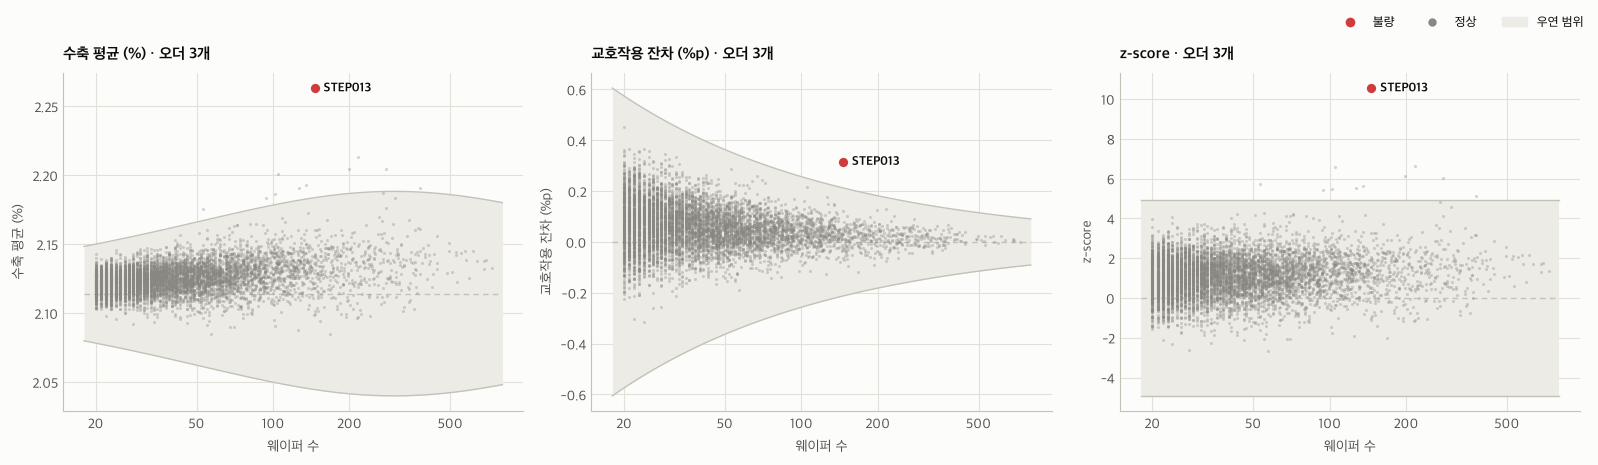

In [15]:
tab = targets[0]['k'] if targets else 2
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, ymode in zip(axes, ('shrunk', 'resid', 'z')):
    plot_funnel(ax, tab, ymode, mark)
    ax.set_title(f'{Y_LABEL[ymode]} · 오더 {tab}개', loc='left')
funnel_legend(fig)
plt.tight_layout()
plt.show()

**불량 조합 목록** (웹과 같이 평균이 높은 순). `SHOW_REL = True`면 관련 조합도 함께 보여 줍니다.

In [16]:
def combo_table(cs):
    rows = []
    for c in cs:
        st = steps[c['step']]
        why = STATUS_LABEL[c['status']]
        if c['explained_by'] is not None:
            why += ' ← ' + path_label(st, res['combos'][c['explained_by']]['items'])
        rows.append({'스텝': st['name'], '공정': st['proc'], '오더 수': c['k'], '경로': path_label(st, c['items']),
                     '웨이퍼': c['n'], '평균(%)': c['mean'], '차이(%p)': c['mean'] - res['mu'], 'z': c['z'],
                     '기준 z': zk[c['k']], '부모 대비 t': f"{c['lift_t']:.2f}" if c['k'] >= 2 else '–',
                     '판정': why, 'key': c['key']})
    return pd.DataFrame(rows, index=pd.RangeIndex(1, len(rows) + 1, name='순위'))


print(f'불량 조합 {len(findings)}개' + (f' · 스텝 {STEP}' if STEP else ''))
display(combo_table(findings))
if SHOW_REL:
    print(f'관련 조합 {len(related)}개')
    display(combo_table(related))

불량 조합 4개


,스텝,공정,오더 수,경로,웨이퍼,평균(%),차이(%p),z,기준 z,부모 대비 t,판정,key
순위,,,,,,,,,,,,
1,STEP013,IMP,3,O4:IMP18 → O5:IMP02 → O8:IMP11,146,2.57,0.4556,10.55,4.922,7.67,불량,12|3:3|4:0|7:1
2,STEP050,DIF,2,O2:DIF30 → O3:DIF17,415,2.346,0.2315,9.034,4.638,7.96,불량,49|1:0|2:1
3,STEP056,DIF,2,O1:DIF58 → O3:DIF11,358,2.337,0.223,8.085,4.638,6.19,불량,55|0:2|2:3
4,STEP025,CLN,1,O1:CLN18,1826,2.222,0.1079,8.83,3.991,–,불량,24|0:0


## 6. 조합 상세 (`detail.js`)
불량 조합마다 웹의 상세 패널과 같은 차트를 그립니다.
- **헤더**: 수치 4개와 판정 배지 4개
- **스텝 흐름**: 오더 × 유닛 박스를 유닛 평균으로 색칠하고, 경로를 곡선으로 잇습니다.
- **웨이퍼 분포**: 이 경로 / 오더 하나만 다른 유닛 / 나머지 웨이퍼
- **무작위 비교**: 같은 스텝에서 n장을 뽑은 평균 2,000회. 웹과 같은 난수를 씁니다.
- **오더별 유닛 평균** ± 95% 신뢰구간
- **오더 간 유닛 조합 히트맵**: 오더 3개 조합은 세 번째 오더 = / ≠ 두 장, 단일 유닛은 비교용으로 유닛이 가장 적은 다른 오더
- **시간 추이**: 랏 투입 순서

In [17]:
N_SAMPLE = 2000


def membership(c):
    """이 경로 / 오더 하나만 다른 경로 / 나머지 웨이퍼"""
    A = data['assign'][c['step']][[q for q, _ in c['items']]]
    U = np.array([u for _, u in c['items']])[:, None]
    present = A[0] != MISSING
    mism = A != U
    miss = mism.sum(axis=0)
    me = np.flatnonzero(present & (miss == 0))
    others = np.flatnonzero(present & (miss > 0))
    parents = [np.flatnonzero(present & (miss == 1) & mism[i]) for i in range(c['k'])] if c['k'] >= 2 else []
    return me, others, parents


def box_stats(idx):
    v = np.sort(Y[idx])
    q1, q3 = quantile(v, 0.25), quantile(v, 0.75)
    iqr = q3 - q1
    return {'n': len(v), 'mean': float(v.sum() / len(v)), 'q1': q1, 'med': quantile(v, 0.5), 'q3': q3,
            'lo': max(float(v[0]), q1 - 1.5 * iqr), 'hi': min(float(v[-1]), q3 + 1.5 * iqr),
            'p01': quantile(v, 0.005), 'p99': quantile(v, 0.995)}


def random_means(pool, n, seed):
    """같은 스텝 웨이퍼에서 n장을 뽑은 평균 N_SAMPLE개 (detail.js randomMeans와 같은 난수 · 같은 순서)"""
    P, L, Yl = pool.tolist(), len(pool), Y.tolist()
    us = Rng(seed).take(N_SAMPLE * n).tolist()
    out, k = np.empty(N_SAMPLE), 0
    for t in range(N_SAMPLE):          # 배열은 초기화하지 않고 앞쪽 n개를 이어서 부분 셔플
        s = 0.0
        for i in range(n):
            j = i + int(us[k] * (L - i))
            k += 1
            P[i], P[j] = P[j], P[i]
            s += Yl[P[i]]
        out[t] = s / n
    return out


def cell_means(s, qa, qb, cond=None):
    A, B = data['assign'][s][qa], data['assign'][s][qb]
    ua, ub = len(steps[s]['seqs'][qa]['units']), len(steps[s]['seqs'][qb]['units'])
    ok = A != MISSING
    if cond:
        ok &= (data['assign'][s][cond['q']] == cond['u']) == cond['eq']
    key = A[ok].astype(np.int64) * ub + B[ok]
    return ua, ub, np.bincount(key, minlength=ua * ub), np.bincount(key, weights=Y[ok], minlength=ua * ub)


def rolling(xs, ys, win):
    out, s = [], 0.0
    for i in range(len(ys)):
        s += ys[i]
        if i >= win:
            s -= ys[i - win]
        if i >= win - 1:
            out.append((xs[i - win // 2], s / win))
    return out


def heat_spec(c):
    """히트맵 축: 오더 2개 이상이면 앞 두 오더, 3개면 세 번째 오더 = / ≠, 단일 유닛이면 유닛이 가장 적은 다른 오더"""
    st = steps[c['step']]
    if c['k'] >= 2:
        (qa, ua), (qb, ub) = c['items'][:2]
        conds = [None]
        if c['k'] == 3:
            q3, u3 = c['items'][2]
            conds = [{'q': q3, 'u': u3, 'eq': True}, {'q': q3, 'u': u3, 'eq': False}]
        return {'qa': qa, 'ua': ua, 'qb': qb, 'ub': ub, 'conds': conds}
    qa, ua = c['items'][0]
    other = sorted([q for q, sq in enumerate(st['seqs']) if q != qa and len(sq['units']) >= 2], key=lambda q: len(st['seqs'][q]['units']))
    return {'qa': qa, 'ua': ua, 'qb': other[0], 'ub': -1, 'conds': [None]} if other else None

In [18]:
DIV = LinearSegmentedColormap.from_list('div', [C['low'], C['mid'], C['high']])
DIV.set_bad('#f4f3ef')


def plot_flow(c):
    st, info = steps[c['step']], res['seq_info'][c['step']]
    hit = dict(c['items'])
    colW, gap, boxH, boxGap, top, padX = 84, 26, 22, 4, 42, 2          # detail.js flowSvg와 같은 치수(px → pt)
    nq = len(st['seqs'])
    maxU = max(len(sq['units']) for sq in st['seqs'])
    W = padX * 2 + nq * colW + (nq - 1) * gap
    H = top + maxU * (boxH + boxGap) + 4
    max_dev = max([0.05] + [u['mean'] - res['mu'] for sq in info for u in sq['units'] if not math.isnan(u['mean'])])
    col_x = lambda q: padX + q * (colW + gap)
    box_y = lambda u: top + u * (boxH + boxGap)
    fig = plt.figure(figsize=(W / 72, (H + 26) / 72))
    ax = fig.add_axes((0, 0, 1, H / (H + 26)))
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.axis('off')
    fig.text(0, 1, '스텝 흐름 · 유닛 색 = 평균 불량률', ha='left', va='top', fontsize=11, fontweight='bold', color=C['ink'])
    for q, sq in enumerate(st['seqs']):
        on, cx = q in hit, col_x(q) + colW / 2
        an_ = info[q]['anova']
        sub = '유닛 1개' if not info[q]['testable'] else (f"p {fmt_p(an_['p'])}" if an_ and an_['p'] < 0.05 else '차이 없음')
        ax.text(cx, 15, f'오더 {q + 1}', ha='center', va='baseline', fontsize=12, fontweight='bold', color=C['bad'] if on else C['ink2'])
        ax.text(cx, 30, sub, ha='center', va='baseline', fontsize=10, color=C['muted'])
        for ui, u in enumerate(info[q]['units']):
            sel = on and hit[q] == ui
            t = 0.0 if math.isnan(u['mean']) else min(1.0, max(0.0, (u['mean'] - res['mu']) / max_dev))
            fill = C['bad'] if sel else mix(C['bad'], C['mid'], round(t * 55) / 100)
            alpha = 1 if on else 0.45
            ax.add_patch(FancyBboxPatch((col_x(q), box_y(ui)), colW, boxH, boxstyle='round,pad=0,rounding_size=6',
                                        fc=fill, ec='none', alpha=alpha, zorder=4 if sel else 3))
            ax.text(cx, box_y(ui) + boxH / 2 + 4, u['name'], ha='center', va='baseline', fontsize=11,
                    fontweight='bold' if sel else 'normal', color='white' if sel else C['ink'], alpha=alpha, zorder=5)
    pts = sorted((col_x(q) + colW / 2, box_y(u) + boxH / 2) for q, u in c['items'])
    if len(pts) > 1:
        verts, codes = [pts[0]], [MplPath.MOVETO]
        for (x0, y0), (x1, y1) in zip(pts, pts[1:]):
            dx = (x1 - x0) / 2
            verts += [(x0 + dx, y0), (x1 - dx, y1), (x1, y1)]
            codes += [MplPath.CURVE4] * 3
        ax.add_patch(PathPatch(MplPath(verts, codes), fc='none', ec=C['bad'], lw=3, alpha=0.85, capstyle='round', zorder=2))
    plt.show()


def plot_dist(ax, c, me, others, parents):
    st = steps[c['step']]
    groups = [('이 경로', me, C['bad'])]
    if c['k'] >= 2:
        groups += [(f"{st['seqs'][q]['name']}만 다른 유닛", parents[i], C['ink2']) for i, (q, _) in enumerate(c['items'])]
    groups.append(('나머지 웨이퍼', others, C['muted']))
    groups = [g for g in groups if len(g[1])]
    sums = [box_stats(idx) for _, idx, _ in groups]
    rng, h = Rng(31 + c['id']), 0.46
    for gi, ((label, idx, col), s_) in enumerate(zip(groups, sums)):
        pick = idx[::max(1, math.ceil(len(idx) / 500))]
        jit = [gi + (rng.u() - 0.5) * 0.5 for _ in range(len(pick))]
        ax.scatter(Y[pick], jit, s=5, color=col, alpha=0.45 if gi == 0 else 0.2, lw=0, zorder=1)
        ax.plot([s_['lo'], s_['hi']], [gi, gi], color=col, lw=1.2, zorder=2)
        ax.add_patch(Rectangle((s_['q1'], gi - h / 2), s_['q3'] - s_['q1'], h, fc=col, alpha=0.16, ec='none', zorder=2))
        ax.add_patch(Rectangle((s_['q1'], gi - h / 2), s_['q3'] - s_['q1'], h, fc='none', ec=col, lw=1.4, zorder=3))
        ax.plot([s_['med']] * 2, [gi - h / 2, gi + h / 2], color=col, lw=2.5, zorder=3)
        ax.scatter([s_['mean']], [gi], marker='D', s=48, color=col, edgecolors=C['surface'], lw=1.5, zorder=4)
        ax.annotate(f"{s_['mean']:.2f}", (s_['mean'], gi - h / 2), xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color=C['ink'], zorder=5)
    ax.axvline(res['mu'], color=C['muted'], ls=(0, (4, 3)), lw=1, zorder=0)
    ax.set_yticks(range(len(groups)), [g[0] for g in groups])
    ax.set_ylim(len(groups) - 0.5, -0.6)
    ax.set_xlim(math.floor(min(s_['p01'] for s_ in sums) * 10) / 10, math.ceil(max(s_['p99'] for s_ in sums) * 10) / 10)
    ax.set_xlabel('웨이퍼 불량률 (%)')
    ax.set_title('웨이퍼 분포 · 상자 = 사분위 · ◆ = 평균')
    ax.grid(axis='y', visible=False)


def plot_random(ax, c, sims):
    cut = res['mu'] + zk[c['k']] * res['sd'] / math.sqrt(c['n'])
    lo, hi = float(sims.min()), float(sims.max())
    top, bins = max(hi, c['mean'], cut), 40
    w = (hi - lo) / bins or 1e-3
    counts = np.bincount(np.minimum(bins - 1, ((sims - lo) / w).astype(int)), minlength=bins)
    ax.bar(lo + (np.arange(bins) + 0.5) * w, counts, width=w * 0.85, color=C['muted'], alpha=0.6)
    ax.axvline(cut, color=C['ink2'], ls=(0, (4, 3)), lw=1.2)
    ax.axvline(c['mean'], color=C['bad'], lw=2.5)
    ytop = counts.max()
    ax.annotate('보정 기준', (cut, ytop), xytext=(-5, 0), textcoords='offset points', ha='right', va='top', fontsize=9, color=C['ink2'])
    ax.annotate(f"이 경로 {c['mean']:.2f}", (c['mean'], ytop * 0.72), xytext=(5, 0), textcoords='offset points',
                ha='left', va='top', fontsize=9, fontweight='bold', color=C['ink'])
    pad = (top - lo) * 0.06
    ax.set_xlim(lo - pad, top + pad)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.grid(False)
    beyond = int((sims >= c['mean']).sum())
    ax.set_title(f"무작위 {c['n']:,}장 평균 {N_SAMPLE:,}회 · 이 경로 이상 {beyond} / {N_SAMPLE:,}")
    ax.set_xlabel(f"{c['n']:,}장 평균 (%)")


def plot_unit_ci(c):
    st = steps[c['step']]
    maxU = max(len(st['seqs'][q]['units']) for q, _ in c['items'])
    fig, axes = plt.subplots(1, c['k'], figsize=(4.6 * c['k'], 1.1 + 0.3 * maxU), squeeze=False)
    for ax, (q, u) in zip(axes[0], c['items']):
        units = res['seq_info'][c['step']][q]['units']
        for ui, x in enumerate(units):
            h = 1.96 * (x['sd'] / math.sqrt(max(1, x['n'])))
            col = C['bad'] if ui == u else C['muted']
            ax.plot([x['mean'] - h, x['mean'] + h], [ui, ui], color=col, lw=2, solid_capstyle='round')
            ax.scatter([x['mean']], [ui], s=60 if ui == u else 30, color=C['bad'] if ui == u else C['ink2'],
                       edgecolors=C['surface'], lw=1.2, zorder=3)
        ax.axvline(res['mu'], color=C['muted'], ls=(0, (4, 3)), lw=1)
        ax.set_yticks(range(len(units)), [x['name'] for x in units])
        ax.set_ylim(len(units) - 0.5, -0.5)
        an_ = res['seq_info'][c['step']][q]['anova']
        ax.set_title(f"{st['seqs'][q]['name']} · 유닛 간 p {fmt_p(an_['p'])}" if an_ else st['seqs'][q]['name'])
        ax.set_xlabel('평균 불량률 (%) ± 95% CI')
        ax.grid(axis='y', visible=False)
    fig.suptitle('오더별 유닛 평균', x=0.01, ha='left', fontsize=11, fontweight='bold', color=C['ink'])
    plt.tight_layout()
    plt.show()


def plot_heat(ax, c, spec, cond, grid, span):
    st = steps[c['step']]
    ua_n, ub_n, n_, sm = grid
    M = np.full((ub_n, ua_n), np.nan)
    for a in range(ua_n):
        for b in range(ub_n):
            if n_[a * ub_n + b] >= 5:
                M[b, a] = sm[a * ub_n + b] / n_[a * ub_n + b]
    ax.imshow(np.ma.masked_invalid(M), cmap=DIV, vmin=res['mu'] - span, vmax=res['mu'] + span, aspect='auto', interpolation='nearest')
    for x in np.arange(-0.5, ua_n):
        ax.axvline(x, color=C['surface'], lw=2)
    for y in np.arange(-0.5, ub_n):
        ax.axhline(y, color=C['surface'], lw=2)
    for a in range(ua_n):
        for b in range(ub_n):
            if a == spec['ua'] and (spec['ub'] < 0 or b == spec['ub']) and (not cond or cond['eq']):
                ax.add_patch(Rectangle((a - 0.5, b - 0.5), 1, 1, fill=False, ec=C['ink'], lw=2, zorder=3))
            if ua_n * ub_n <= 64 and not math.isnan(M[b, a]):
                ax.text(a, b, f'{M[b, a]:.2f}', ha='center', va='center', fontsize=8, color=C['ink'])
    ua_names, ub_names = st['seqs'][spec['qa']]['units'], st['seqs'][spec['qb']]['units']
    ax.set_xticks(range(ua_n), ua_names, rotation=45 if ua_n > 6 else 0, ha='right' if ua_n > 6 else 'center')
    ax.set_yticks(range(ub_n), ub_names)
    ax.set_xlabel(st['seqs'][spec['qa']]['name'])
    ax.set_ylabel(st['seqs'][spec['qb']]['name'])
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    title = f"{st['seqs'][spec['qa']]['name']} × {st['seqs'][spec['qb']]['name']}" + (' (비교용)' if c['k'] == 1 else '')
    if cond:
        title = f"{st['seqs'][cond['q']]['name']} {'=' if cond['eq'] else '≠'} {st['seqs'][cond['q']]['units'][cond['u']]}"
    ax.set_title(title)


def plot_time(ax, me, pool):
    all_x = np.sort(pool)
    all_roll = rolling(all_x.tolist(), Y[all_x].tolist(), 250)[::10]
    me_y = Y[me]
    win = max(8, min(60, math.floor(len(me) / 8 + 0.5)))
    me_roll = rolling(me.tolist(), me_y.tolist(), win)
    ax.scatter(me, me_y, s=5, color=C['bad'], alpha=0.25, lw=0, label='이 경로 웨이퍼')
    if all_roll:
        ax.plot(*zip(*all_roll), color=C['muted'], lw=2, label='전체 이동평균')
    if me_roll:
        ax.plot(*zip(*me_roll), color=C['bad'], lw=2.5, label='이 경로 이동평균')
    vals = [v for _, v in all_roll + me_roll]
    ax.set_ylim(math.floor(min(vals + [res['mu']]) * 20) / 20 - 0.1, math.ceil(max(vals) * 20) / 20 + 0.1)
    ax.set_xlim(0, N)
    wpl = data['cfg']['waferPerLot']
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'L{int(min(max(v, 0), N - 1)) // wpl + 1}'))
    ax.set(title='시간 추이', xlabel='랏 투입 순서', ylabel='불량률 (%)')
    ax.legend(loc='lower right', bbox_to_anchor=(1, 1.0), ncol=3, borderaxespad=0.3)


def show_detail(c):
    st = steps[c['step']]
    d = c['mean'] - res['mu']
    badges = [(c['z'] > Z998, '99.8% 범위 밖'), (c['over'], '보정 기준 밖'),
              (c['lift_t'] > zk[c['k']], '오더 하나 뺀 경로보다 높음') if c['k'] >= 2 else (True, '단일 유닛'),
              (c['status'] != 'explained', '최소 원인 단위')]
    print(f"■ {st['name']} · {st['proc']} · 오더 {len(st['seqs'])}개 중 {c['k']}개 경로 · {STATUS_LABEL[c['status']]}")
    print(f"  경로  {path_label(st, c['items'])}")
    print(f"  전체 평균 대비 {d:+.2f}%p · 경로 평균 {c['mean']:.2f}% · 웨이퍼 {c['n']:,}장 · z {c['z']:.1f} / 보정 기준 {zk[c['k']]:.1f}")
    print('  ' + '   '.join(('✓ ' if ok else '✗ ') + t for ok, t in badges))
    me, others, parents = membership(c)
    pool = np.concatenate([me, others])
    plot_flow(c)

    rows = len(c['items']) + 2 if c['k'] >= 2 else 2
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 1.6 + 0.62 * rows), gridspec_kw={'width_ratios': [1.3, 1]})
    plot_dist(a1, c, me, others, parents)
    plot_random(a2, c, random_means(pool, c['n'], 7919 + c['id']))
    plt.tight_layout()
    plt.show()

    plot_unit_ci(c)

    spec = heat_spec(c)
    conds = spec['conds'] if spec else []
    grids = [cell_means(c['step'], spec['qa'], spec['qb'], cd) for cd in conds]
    span = 0.05
    for _, _, n_, sm in grids:
        ok = n_ >= 5
        if ok.any():
            span = max(span, float(np.abs(sm[ok] / n_[ok] - res['mu']).max()))
    ub_n = grids[0][1] if grids else 4
    fig, axes = plt.subplots(1, len(conds) + 1, figsize=(4.2 * len(conds) + 8, max(3.2, 1.2 + 0.32 * ub_n)),
                             gridspec_kw={'width_ratios': [1] * len(conds) + [1.9]}, squeeze=False)
    for ax, cd, g in zip(axes[0], conds, grids):
        plot_heat(ax, c, spec, cd, g, span)
    plot_time(axes[0][-1], me, pool)
    plt.tight_layout()
    plt.show()

■ STEP013 · IMP · 오더 8개 중 3개 경로 · 불량
  경로  O4:IMP18 → O5:IMP02 → O8:IMP11
  전체 평균 대비 +0.46%p · 경로 평균 2.57% · 웨이퍼 146장 · z 10.5 / 보정 기준 4.9
  ✓ 99.8% 범위 밖   ✓ 보정 기준 밖   ✓ 오더 하나 뺀 경로보다 높음   ✓ 최소 원인 단위


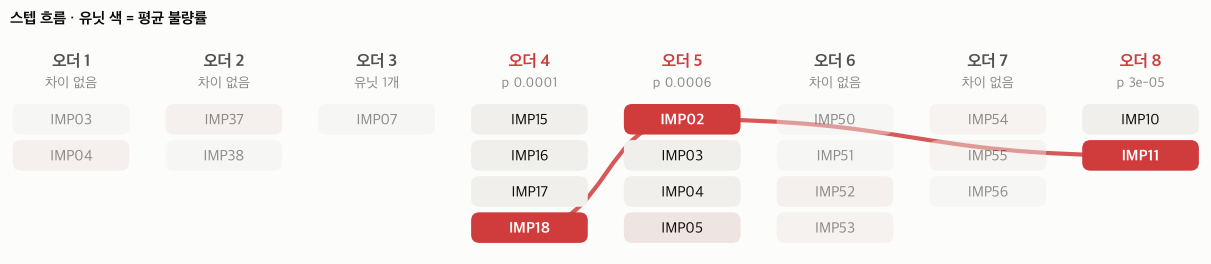

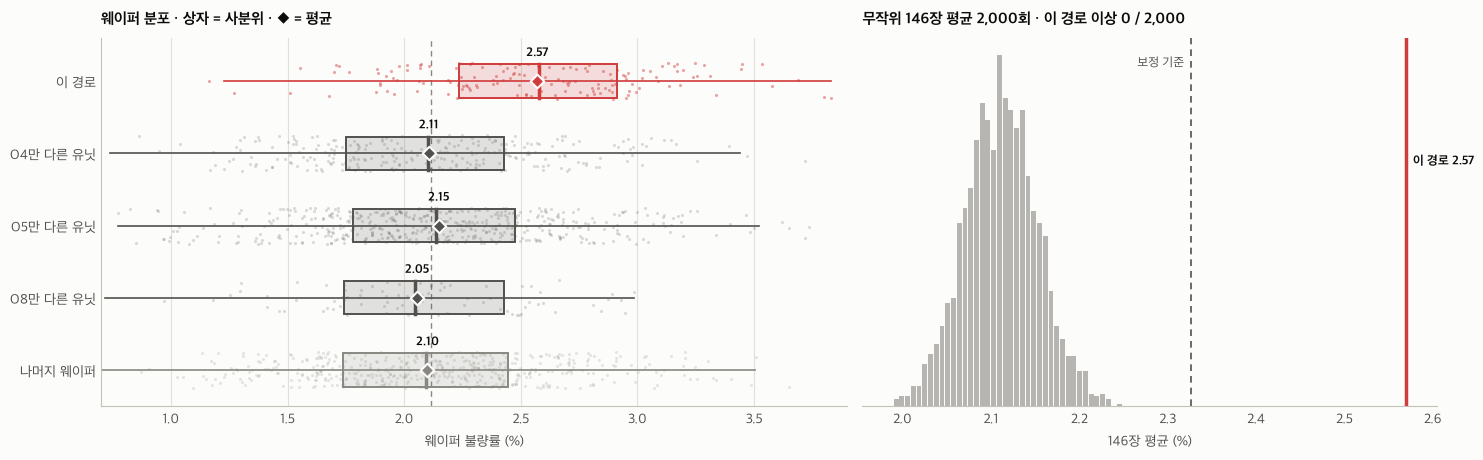

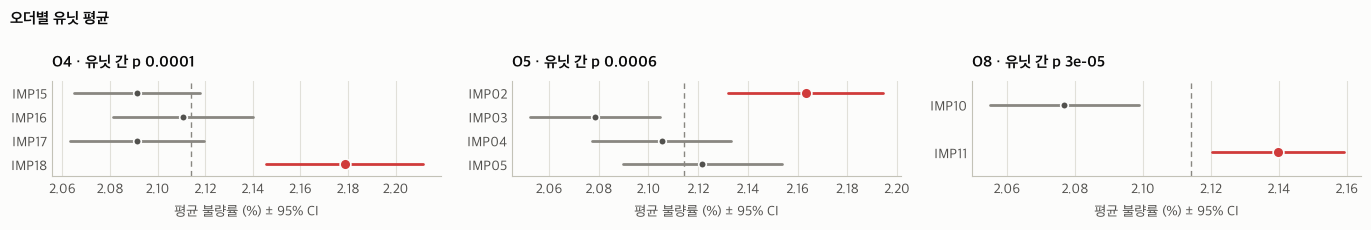

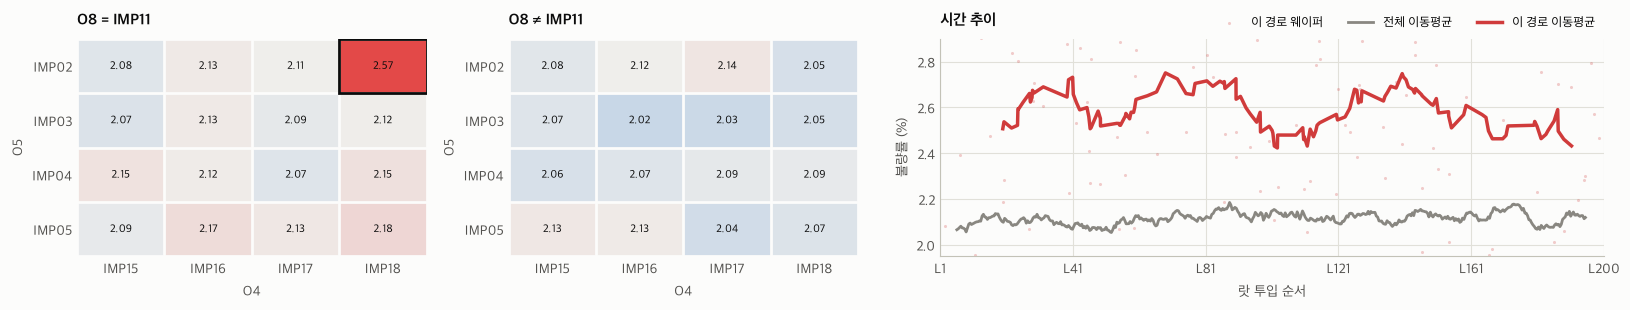

■ STEP050 · DIF · 오더 4개 중 2개 경로 · 불량
  경로  O2:DIF30 → O3:DIF17
  전체 평균 대비 +0.23%p · 경로 평균 2.35% · 웨이퍼 415장 · z 9.0 / 보정 기준 4.6
  ✓ 99.8% 범위 밖   ✓ 보정 기준 밖   ✓ 오더 하나 뺀 경로보다 높음   ✓ 최소 원인 단위


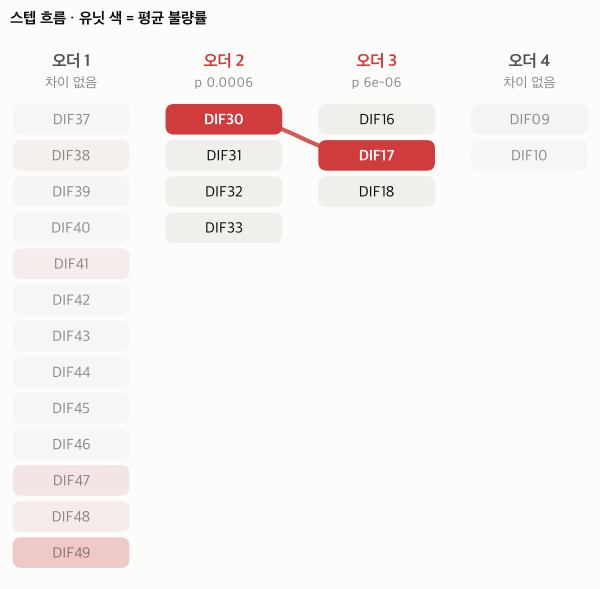

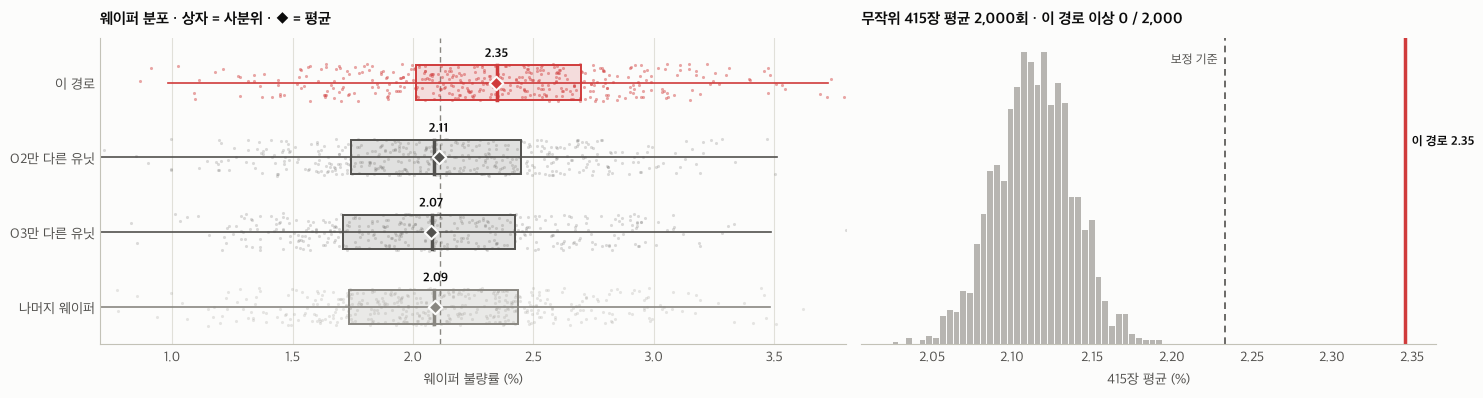

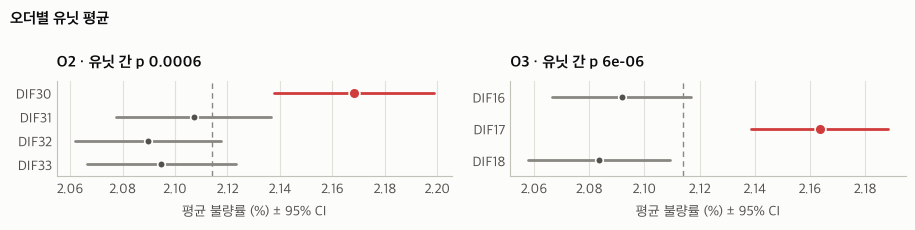

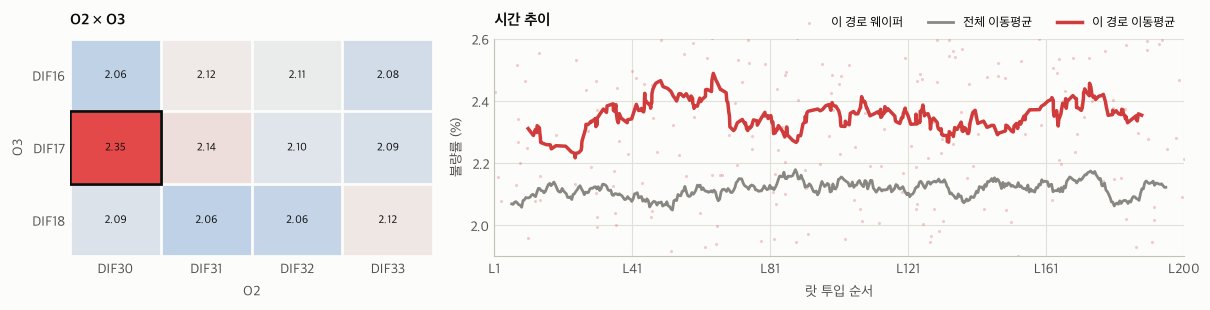

■ STEP056 · DIF · 오더 4개 중 2개 경로 · 불량
  경로  O1:DIF58 → O3:DIF11
  전체 평균 대비 +0.22%p · 경로 평균 2.34% · 웨이퍼 358장 · z 8.1 / 보정 기준 4.6
  ✓ 99.8% 범위 밖   ✓ 보정 기준 밖   ✓ 오더 하나 뺀 경로보다 높음   ✓ 최소 원인 단위


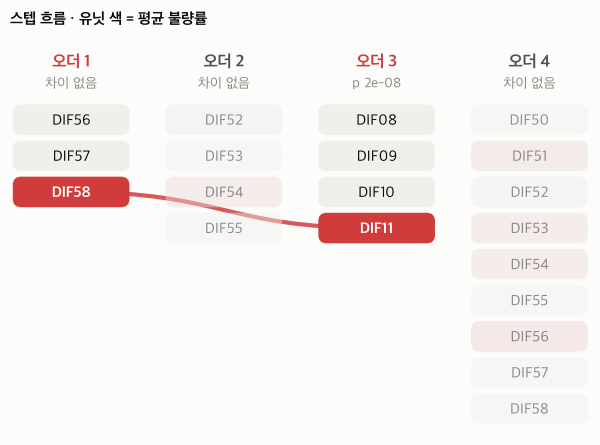

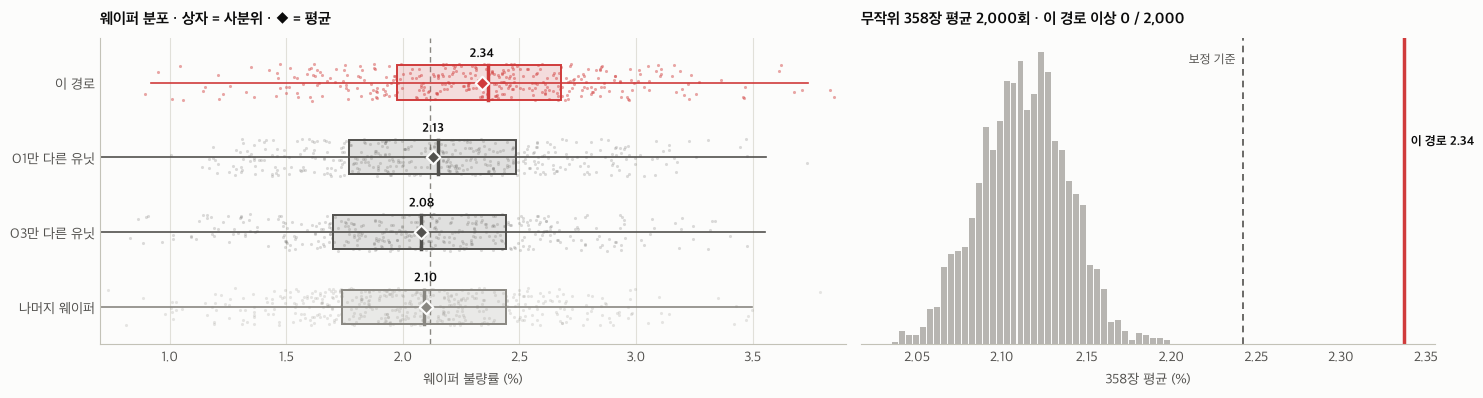

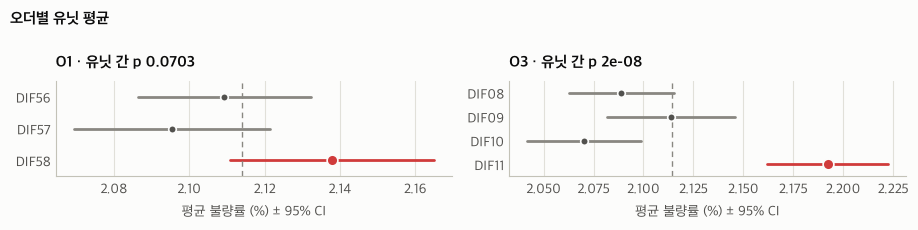

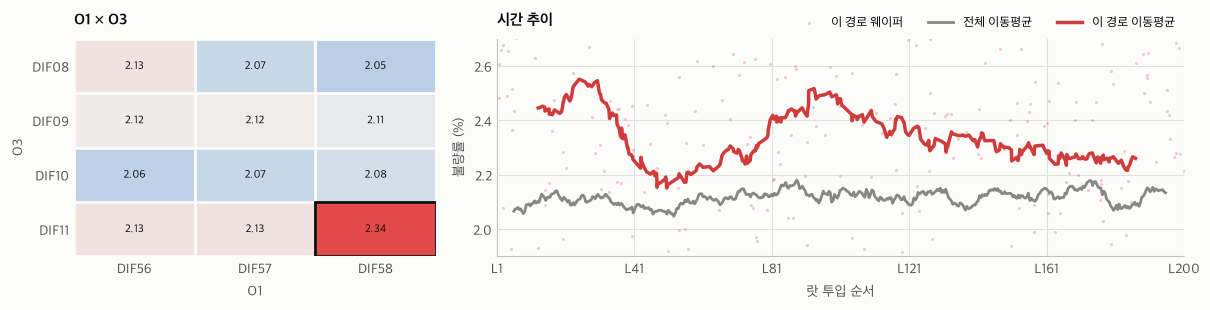

■ STEP025 · CLN · 오더 2개 중 1개 경로 · 불량
  경로  O1:CLN18
  전체 평균 대비 +0.11%p · 경로 평균 2.22% · 웨이퍼 1,826장 · z 8.8 / 보정 기준 4.0
  ✓ 99.8% 범위 밖   ✓ 보정 기준 밖   ✓ 단일 유닛   ✓ 최소 원인 단위


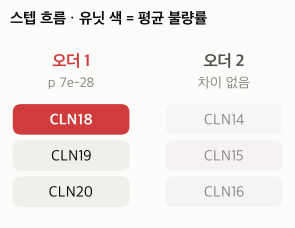

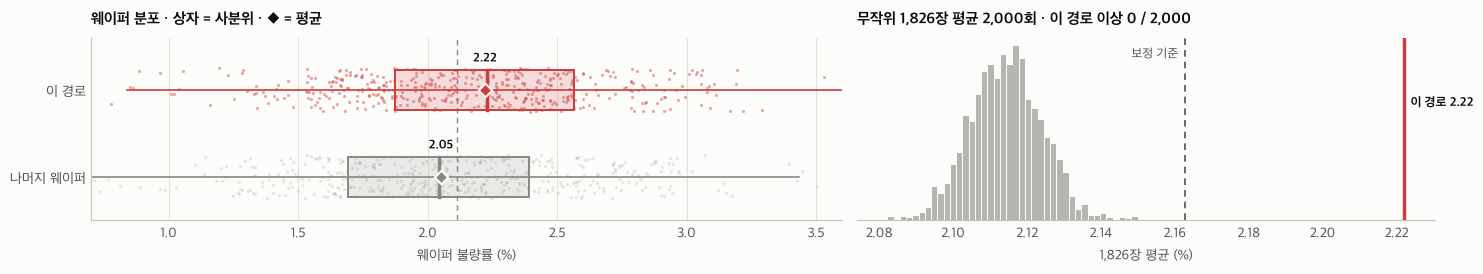

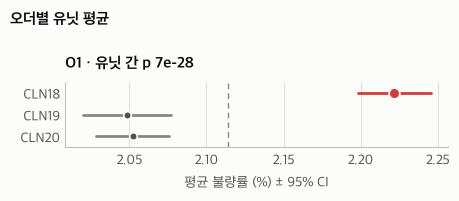

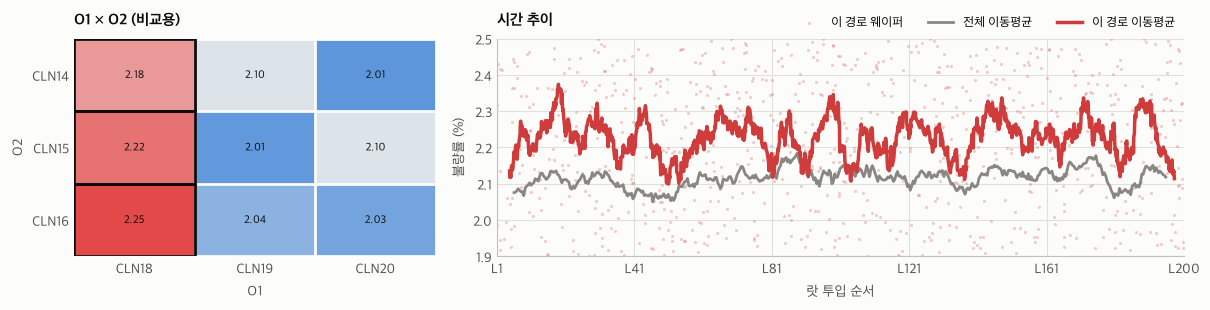

In [19]:
for c in targets:
    show_detail(c)

## 7. 로직 점검
### 7-1. JS 결과와 대조
같은 시드로 main의 JS(`js/mock.js`, `js/analysis.js`, `js/permWorker.js`)를 Node로 실행해서, 이 노트북의 결과와 값 단위로 맞춰 봅니다. 실행 스크립트는 `notebooks/js_reference.mjs`입니다.

In [20]:
node = shutil.which('node')
js = None
if node is None:
    print('Node.js를 찾지 못해 JS 대조를 건너뜁니다.')
else:
    t0 = time.perf_counter()
    out = subprocess.run([node, str(REPO / 'notebooks' / 'js_reference.mjs'), str(SEED), str(MIN_N), str(N_PERM)],
                         capture_output=True, text=True, check=True)
    js = json.loads(out.stdout)
    rows = []

    def row(name, ok, detail=''):
        rows.append({'항목': name, '결과': '✓ 일치' if ok else '✗ 다름', '내용': detail})

    def close(a, b, rtol=1e-9, atol=1e-12):
        a = np.array([np.nan if v is None else v for v in a], dtype=float)
        b = np.array([np.nan if v is None else v for v in b], dtype=float)
        ok = np.allclose(a, b, rtol=rtol, atol=atol, equal_nan=True)
        with np.errstate(all='ignore'):
            dev = np.nanmax(np.abs(a - b)) if len(a) else 0.0
        return bool(ok), float(dev)

    dy = float(np.max(np.abs(np.array(js['Y']) - Y)))
    row('mock 데이터 Y', dy < 1e-12, f'웨이퍼 {N:,}장 · 최대 차이 {dy:.1e}')
    row('μ · σ', abs(js['mu'] - res['mu']) < 1e-12 and abs(js['sd'] - res['sd']) < 1e-12, f"μ {js['mu']:.6f} · σ {js['sd']:.6f}")
    row('깊이별 조합 수', js['depthCount'][1:] == res['depth_count'][1:], str(js['depthCount'][1:]))
    row('탐색 공간', js['searchSpace'][1:] == res['search_space'][1:], str(js['searchSpace'][1:]))
    jc = js['combos']
    row('조합 key와 순서', [c[0] for c in jc] == [c['key'] for c in res['combos']], f'{len(jc):,}개')
    row('조합별 웨이퍼 수', [c[1] for c in jc] == [c['n'] for c in res['combos']])
    for name, j, key in (('z', 2, 'z'), ('리프트 p', 3, 'lift_p'), ('부모 대비 t', 4, 'lift_t'), ('q-value', 5, 'q'),
                         ('수축 평균', 6, 'shrunk'), ('교호작용 잔차', 7, 'resid')):
        ok, dev = close([c[j] for c in jc], [c[key] for c in res['combos']])
        row(f'조합별 {name}', ok, f'최대 차이 {dev:.1e}')
    ok, dev = close([js['kappa'], js['kappaRaw']], [res['kappa'], res['kappa_raw']])
    row('수축 κ', ok, f"κ {js['kappa']:.0f} (원값 {js['kappaRaw']:.3g})")
    if js['permZ']:
        ok, dev = close(js['permZ'][1:], perm_z[1:])
        row('순열 검정 기준선', ok, ' · '.join(f'{v:.3f}' for v in js['permZ'][1:]))
    for env, v in js['envs'].items():
        ok, dev = close(v['zk'][1:], zks[env][1:])
        classify(res, zks[env])
        diff = sum(a != c['status'] for a, c in zip(v['status'], res['combos']))
        row(f'판정 · {ENV_LABEL[env]}', ok and diff == 0, f"기준 z {' · '.join(f'{z:.3f}' for z in v['zk'][1:])} · 판정 다른 조합 {diff}개 · 불량 {v['summary']['bad']}")
    summary = classify(res, zk)                  # 선택한 기준으로 되돌림
    print(f'Node 실행 포함 {time.perf_counter() - t0:.1f}초')
    display(pd.DataFrame(rows).set_index('항목'))

Node 실행 포함 1.6초


,결과,내용
항목,,
mock 데이터 Y,✓ 일치,"웨이퍼 5,000장 · 최대 차이 4.4e-16"
μ · σ,✓ 일치,μ 2.114105 · σ 0.521972
깊이별 조합 수,✓ 일치,"[1519, 28384, 7137]"
탐색 공간,✓ 일치,"[1519, 28384, 116845]"
조합 key와 순서,✓ 일치,"37,040개"
조합별 웨이퍼 수,✓ 일치,
조합별 z,✓ 일치,최대 차이 7.9e-14
조합별 리프트 p,✓ 일치,최대 차이 7.7e-13
조합별 부모 대비 t,✓ 일치,최대 차이 7.8e-14


### 7-2. 여러 시드
시드를 바꿔 가며(현재 main 규칙) 심어 둔 불량을 찾는지, 정답이 아닌 조합이 불량으로 남는지 봅니다. 정답이 아닌 불량은 두 종류로 나눕니다.
- **진짜 불량과 겹침**: 진짜 불량 조합과 유닛을 공유합니다(예: 진짜 불량에 오더를 하나 더 붙인 조합).
- **무관**: 순수한 우연입니다.

In [21]:
def run_seed(seed, method='bonf', **gen):
    d = generate(seed, **gen)
    r = analyze(d, min_n=MIN_N)
    z = thresholds(r, method)
    classify(r, z)
    return d, r, z


def truth_keys(d):
    return {combo_key(e['step'], tuple(sorted(e['items']))) for e in d['effects']}


def shared_effect(d, c):
    """같은 스텝에서 유닛을 공유하는 심어 둔 불량"""
    for e in d['effects']:
        if e['step'] == c['step'] and set(c['items']) & set(e['items']):
            return e
    return None


def fp_kind(d, c):
    if not (e := shared_effect(d, c)):
        return '무관'
    shared = len(set(c['items']) & set(e['items']))
    return '진짜 불량 + 오더 추가' if shared == len(e['items']) else f'진짜 불량과 유닛 {shared}개 공유'


t0 = time.perf_counter()
seed_rows, fp_rows, lift_rows, old_rows = [], [], [], []
for sd_ in CHECK_SEEDS:
    d, r, z = run_seed(sd_)
    tk = truth_keys(d)
    tc = truth_check(d, r)
    fps = [c for c in r['combos'] if c['status'] == 'bad' and c['key'] not in tk]
    for c in fps:
        st = d['steps'][c['step']]
        fp_rows.append({'시드': sd_, '스텝': st['name'] + (' (함정)' if st['decoy'] else ''), '오더 수': c['k'],
                        '경로': path_label(st, c['items']), '웨이퍼': c['n'], 'z': c['z'], '기준 z': z[c['k']],
                        '부모 대비 t': c['lift_t'], '종류': fp_kind(d, c)})
    seed_rows.append({'시드': sd_, '탐지': f"{sum(t['status'] == 'bad' for t in tc)}/4",
                      '놓친 정답': ', '.join(TYPE_LABEL[t['effect']['type']] for t in tc if t['status'] != 'bad') or '–',
                      '정답 외 불량': len(fps)})
    # 7-3 비교용: 이전 규칙(리프트 p < 0.001)으로 다시 판정
    classify(r, z, lift_rule='p')
    ofp = [c for c in r['combos'] if c['status'] == 'bad' and c['key'] not in tk]
    old_rows.append((sum(t['combo'] is not None and t['combo']['status'] == 'bad' for t in tc),
                     sum(fp_kind(d, c) != '무관' for c in ofp), sum(fp_kind(d, c) == '무관' for c in ofp)))
    # 이전 규칙에서 리프트 검정을 받은 '겹치는 조합': 진짜 불량과 유닛을 공유하고(진짜 불량의 부분 조합은 제외) 기준을 넘은 조합
    at_risk = [c for c in r['combos'] if c['k'] >= 2 and c['over'] and c['key'] not in tk and (e := shared_effect(d, c))
               and not set(c['items']) < set(e['items'])]
    lift_rows.append((len(at_risk), sum(c['status'] == 'bad' for c in at_risk)))
fp_df = pd.DataFrame(fp_rows)
seed_df = pd.DataFrame(seed_rows).set_index('시드')
hits = sum(int(s.split('/')[0]) for s in seed_df['탐지'])
print(f'시드 {len(seed_df)}개 · {time.perf_counter() - t0:.0f}초 · 심어 둔 불량 {hits}/{4 * len(seed_df)} 탐지 · '
      f'정답 외 불량 {len(fp_df)}건 (시드 {(seed_df["정답 외 불량"] > 0).sum()}개)')
display(seed_df.T)
if len(fp_df):
    display(fp_df.set_index(['시드', '스텝']))

시드 20개 · 24초 · 심어 둔 불량 79/80 탐지 · 정답 외 불량 1건 (시드 1개)


시드,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
탐지,4/4,4/4,4/4,4/4,4/4,4/4,4/4,4/4,4/4,4/4,4/4,3/4,4/4,4/4,4/4,4/4,4/4,4/4,4/4,4/4
놓친 정답,–,–,–,–,–,–,–,–,–,–,–,오더 2개 조합,–,–,–,–,–,–,–,–
정답 외 불량,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


,,오더 수,경로,웨이퍼,z,기준 z,부모 대비 t,종류
시드,스텝,,,,,,,
9,STEP055,2,O1:MET04 → O3:MET10,66,5.073,4.691,5.137,무관


### 7-3. 알려진 약점
**(a) 리프트 규칙 (바꾼 부분)**: 진짜 불량과 유닛을 공유하는 조합은 효과를 물려받아 기준을 쉽게 넘습니다. 이 조합이 불량인지는 부모 대비 리프트 하나로 가려집니다.

이전 규칙은 리프트 p < 0.001이었습니다. 그런데 기준을 넘었다는 사실 자체가 '평균이 우연히 높게 뽑혔다'는 뜻이라, 같은 데이터로 다시 한 검정은 명목 0.1%보다 훨씬 자주 통과했습니다. 후보도 많아 다중비교 문제까지 겹쳤습니다.

그래서 main은 **부모 대비 Welch t도 같은 기준 z를 넘어야 불량**으로 남기도록 바꿨습니다. 두 규칙을 같은 시드로 비교합니다.

In [22]:
n_risk, n_pass = map(sum, zip(*lift_rows))
print(f'이전 규칙: 시드 {len(lift_rows)}개에서 리프트 검정을 받은 "겹치는 조합" {n_risk}개 → 불량으로 통과 {n_pass}개 '
      f'({n_pass / max(1, n_risk):.1%}, 명목 {LIFT_ALPHA:.1%})')
o_hit, o_rel, o_unrel = map(sum, zip(*old_rows))
fp_rel = int((fp_df['종류'] != '무관').sum()) if len(fp_df) else 0
fp_unrel = int((fp_df['종류'] == '무관').sum()) if len(fp_df) else 0
lift_df = pd.DataFrame([
    {'규칙': '이전: 리프트 p < 0.001', '심어 둔 불량 탐지': f'{o_hit}/{4 * len(seed_df)}', '정답 외 불량 · 진짜 불량과 겹침': o_rel, '정답 외 불량 · 무관': o_unrel},
    {'규칙': '현재 main: 부모 대비 t > 기준 z', '심어 둔 불량 탐지': f'{hits}/{4 * len(seed_df)}', '정답 외 불량 · 진짜 불량과 겹침': fp_rel, '정답 외 불량 · 무관': fp_unrel},
]).set_index('규칙')
display(lift_df)

이전 규칙: 시드 20개에서 리프트 검정을 받은 "겹치는 조합" 119개 → 불량으로 통과 3개 (2.5%, 명목 0.1%)


,심어 둔 불량 탐지,정답 외 불량 · 진짜 불량과 겹침,정답 외 불량 · 무관
규칙,,,
이전: 리프트 p < 0.001,80/80,3,4
현재 main: 부모 대비 t > 기준 z,79/80,0,1


**(b) 수축 평균의 κ**: 조합 간 분산 τ²를 오더 1개 조합에서 추정하는데, 대부분 유닛이 정상이면 τ²가 0 근처라 κ가 발산하고, 코드에 넣은 상한 300이 그대로 쓰입니다. 그래서 funnel의 '수축 평균' 보기는 데이터에서 추정한 값이 아니라 이 상한값으로 정해집니다.

In [23]:
display(pd.DataFrame([{
    '조합 간 분산 vm': res['vm'], '표본오차 분산 v̄': res['vbar'], 'τ² = max(vm − v̄, 1e-12)': res['tau2'],
    'κ 원값 = σ²/τ²': res['kappa_raw'], '사용한 κ (5~300)': res['kappa'],
}], index=['기본 시드']).T.rename(columns={'기본 시드': '값'}))

,값
조합 간 분산 vm,0.0003925
표본오차 분산 v̄,0.0004435
"τ² = max(vm − v̄, 1e-12)",1e-12
κ 원값 = σ²/τ²,2.725e+11
사용한 κ (5~300),300


**(c) 랏 구조** (README의 한계): mock은 유닛을 웨이퍼마다 독립으로 배정하고 랏 간 편차가 없습니다. 실제처럼 한 랏이 같은 유닛을 지나거나 랏마다 수준이 다르면 어떻게 되는지, **불량을 하나도 심지 않은 데이터**에 랏 구조만 입혀서 불량 판정 수(= 모두 오탐)를 셉니다.

In [24]:
NO_EFFECT = {'effects': {'pair': 0, 'single': 0, 'triple': 0}}


def lot_structured(d, lot_sd, per_lot, seed):
    """per_lot이면 랏 첫 웨이퍼의 유닛 배정을 랏 전체에 복사하고, lot_sd만큼 랏 간 편차를 더한다"""
    wpl, n = d['cfg']['waferPerLot'], d['N']
    lots = np.arange(n) // wpl
    assign = [a[:, lots * wpl] for a in d['assign']] if per_lot else d['assign']
    y = np.maximum(0, d['Y'] + lot_sd * np.random.default_rng(seed).normal(size=n // wpl)[lots])
    return {**d, 'assign': assign, 'Y': y}


SCENARIOS = [('독립 배정 (현재 mock)', 0.0, False), ('랏 간 편차만 (σ_lot 0.3)', 0.3, False),
             ('랏 단위 배정만', 0.0, True), ('랏 단위 배정 + 랏 간 편차', 0.3, True)]
t0 = time.perf_counter()
lot_rows = []
for name, lot_sd, per_lot in SCENARIOS:
    row_ = {'시나리오': name}
    for sd_ in LOT_SEEDS:
        d = lot_structured(generate(sd_, **NO_EFFECT), lot_sd, per_lot, sd_)
        r = analyze(d, min_n=MIN_N)
        classify(r, thresholds(r, 'bonf'))
        row_[f'시드 {sd_}'] = sum(c['status'] == 'bad' for c in r['combos'])
    lot_rows.append(row_)
lot_df = pd.DataFrame(lot_rows).set_index('시나리오')
print(f'불량을 심지 않은 데이터의 불량 판정 수 (모두 오탐) · {time.perf_counter() - t0:.0f}초')
display(lot_df)

불량을 심지 않은 데이터의 불량 판정 수 (모두 오탐) · 19초


,시드 1,시드 2,시드 3
시나리오,,,
독립 배정 (현재 mock),0,0,0
랏 간 편차만 (σ_lot 0.3),0,0,0
랏 단위 배정만,0,0,0
랏 단위 배정 + 랏 간 편차,1952,1690,1178


### 7-4. good/bad(0/1)로 분석할 때
`multi-agent-team` 브랜치는 main과 같은 `analyze()`에 Y 대신 bad=1 / good=0을 넣습니다. 그러면 조합의 평균이 **bad 비율**이 되고, z는 `(조합 bad 비율 − 전체 bad 비율) / (σ/√n)`, σ ≈ √(p(1−p))가 됩니다.

문제는 정규근사입니다. bad 비율이 15% 안팎이고 웨이퍼가 적은 조합에서는 분포가 오른쪽으로 치우쳐, **기준 z를 넘을 실제 확률이 명목값보다 몇 배 큽니다.** 기준선(조합 수 보정)은 명목값을 전제로 만든 것이라 그만큼 오탐이 늘어납니다. 아래는 이항분포로 정확히 계산한 비율입니다.

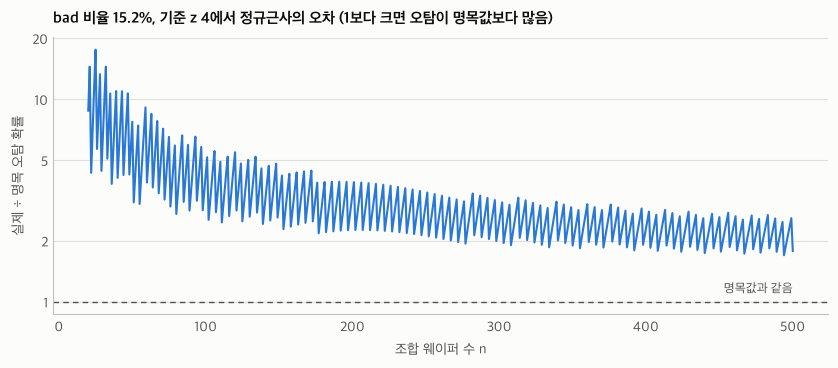

n 20~100 평균 6.1배 · n 100~500 평균 2.7배


In [25]:
P0, Z_THR = 0.152, 4.0          # multi-agent-team 실습 데이터의 전체 bad 비율, 대표 기준 z
ns = np.arange(20, 501)
sd0 = math.sqrt(P0 * (1 - P0))
kk = np.floor(ns * P0 + Z_THR * sd0 * np.sqrt(ns)) + 1          # z > Z_THR 이 되는 최소 bad 수
actual = ibeta(np.full(len(ns), P0), kk, ns - kk + 1)            # 이항 P(X ≥ kk)
nominal = float(norm_sf(Z_THR)[()])
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(ns, actual / nominal, color=C['accent'], lw=1.5)
ax.axhline(1, color=C['ink2'], lw=1, ls=(0, (4, 3)))
ax.annotate('명목값과 같음', (ns[-1], 1), xytext=(0, 4), textcoords='offset points', ha='right', va='bottom', fontsize=9, color=C['ink2'])
ax.set(yscale='log', xlabel='조합 웨이퍼 수 n', ylabel='실제 ÷ 명목 오탐 확률',
       title=f'bad 비율 {P0:.1%}, 기준 z {Z_THR:.0f}에서 정규근사의 오차 (1보다 크면 오탐이 명목값보다 많음)')
plain_log(ax.yaxis)
ax.grid(axis='x', visible=False)
plt.show()
print(f'n 20~100 평균 {np.mean((actual / nominal)[ns <= 100]):.1f}배 · n 100~500 평균 {np.mean((actual / nominal)[ns > 100]):.1f}배')

### 7-5. bad와 value를 함께 쓰면 오탐이 줄어드는가
같은 mock 데이터를 여섯 가지 방식으로 판정해 비교합니다. good/bad는 `multi-agent-team` 실습 데이터와 같은 규칙(value 상위 15% = bad)으로 붙입니다. ⑥을 뺀 모든 방식은 현재 main의 리프트 규칙(부모 대비 t > 기준 z)을 씁니다.

| 방식 | 설명 |
|---|---|
| ① value 평균 (main) | 연속값 value를 그대로 Y로 씁니다. |
| ② bad 비율 · 정규근사 | `multi-agent-team`처럼 bad=1/good=0을 Y로 넣고 main 로직을 그대로 씁니다. (그 브랜치의 분석 코드는 아직 이전 리프트 규칙입니다.) |
| ③ bad 비율 · 정확 이항검정 | z를 이항분포의 정확한 꼬리확률로 계산합니다(`z_method='binom'`). |
| ④ ③ + value 평균 확인 | ③에서 불량인 조합 중 value 평균도 value 기준 z를 넘는 것만 남깁니다. |
| ⑤ ① + bad 비율 확인 | ①에서 불량인 조합 중 bad 비율(정확 검정)도 기준 z를 넘는 것만 남깁니다. |
| ⑥ ① · 이전 리프트 규칙 | ①을 이전 규칙(리프트 p < 0.001)으로 판정합니다. 규칙을 바꾼 효과를 봅니다. |

지표는 세 가지입니다.
- 불량을 심은 데이터에서 **정답 탐지율**(유형별)과 **정답 외 불량 수**
- 불량을 심지 않은 데이터에서 **오탐 수**

In [26]:
METHODS = {'value': '① value 평균 (main)', 'bad_normal': '② bad 비율 · 정규근사', 'bad_exact': '③ bad 비율 · 정확 이항검정',
           'bad_exact_value': '④ ③ + value 평균 확인', 'value_bad': '⑤ ① + bad 비율 확인', 'value_old': '⑥ ① · 이전 리프트 규칙'}


def to_bad(d, top=0.15):
    """value 상위 15%를 bad(1)로 (multi-agent-team gen_practice.mjs와 같은 규칙)"""
    cut = np.sort(d['Y'])[math.floor(d['N'] * (1 - top))]
    return {**d, 'Y': (d['Y'] >= cut).astype(float)}


def members_of(d, c):
    A = d['assign'][c['step']]
    m = A[c['items'][0][0]] != MISSING
    for q, u in c['items']:
        m &= A[q] == u
    return m


def evaluate(d):
    """한 데이터셋을 여섯 방식으로 판정 → {방식: 불량 조합 key 집합}"""
    rv = analyze(d, min_n=MIN_N)                                  # ① value
    zv = thresholds(rv, 'bonf')
    classify(rv, zv)
    db = to_bad(d)
    rn = analyze(db, min_n=MIN_N)                                 # ② bad 비율 · 정규근사
    classify(rn, thresholds(rn, 'bonf'))
    rb = analyze(db, min_n=MIN_N, z_method='binom')               # ③ bad 비율 · 정확 이항검정
    zb = thresholds(rb, 'bonf')
    classify(rb, zb)
    def bad(r):
        return [c for c in r['combos'] if c['status'] == 'bad']

    def value_z(c):          # 조합 웨이퍼의 value 평균 z
        m = members_of(d, c)
        return (d['Y'][m].mean() - rv['mu']) / (rv['sd'] / math.sqrt(m.sum()))

    def bad_z(c):            # 조합 웨이퍼의 bad 비율 z (정확 이항검정)
        m = members_of(d, c)
        return rb['z_one'](int(m.sum()), float(db['Y'][m].sum()))

    out = {
        'value': {c['key'] for c in bad(rv)},
        'bad_normal': {c['key'] for c in bad(rn)},
        'bad_exact': {c['key'] for c in bad(rb)},
        'bad_exact_value': {c['key'] for c in bad(rb) if value_z(c) > zv[c['k']]},
        'value_bad': {c['key'] for c in bad(rv) if bad_z(c) > zb[c['k']]},
    }
    classify(rv, zv, lift_rule='p')
    out['value_old'] = {c['key'] for c in bad(rv)}
    return out


t0 = time.perf_counter()
agg = {m: {'hit': defaultdict(int), 'fp': 0, 'null_fp': 0, 'null_runs_fp': 0} for m in METHODS}
for sd_ in EXP_SEEDS:
    d = generate(sd_)
    tk = {combo_key(e['step'], tuple(sorted(e['items']))): e['type'] for e in d['effects']}
    for m, keys in evaluate(d).items():
        for key in keys & tk.keys():
            agg[m]['hit'][tk[key]] += 1
        agg[m]['fp'] += len(keys - tk.keys())
    for m, keys in evaluate(generate(sd_, **NO_EFFECT)).items():
        agg[m]['null_fp'] += len(keys)
        agg[m]['null_runs_fp'] += bool(keys)
n_exp = len(EXP_SEEDS)
exp_df = pd.DataFrame([{
    '방식': METHODS[m], '정답 탐지': f"{sum(a['hit'].values())}/{4 * n_exp}",
    '오더 2개 (+0.25)': f"{a['hit']['pair']}/{2 * n_exp}", '단일 유닛 (+0.15)': f"{a['hit']['single']}/{n_exp}",
    '오더 3개 (+0.45)': f"{a['hit']['triple']}/{n_exp}",
    '정답 외 불량 (불량 심은 데이터)': a['fp'], '오탐 (불량 없는 데이터)': a['null_fp'],
    '오탐이 나온 시드': f"{a['null_runs_fp']}/{n_exp}",
} for m, a in agg.items()]).set_index('방식')
print(f'시드 {n_exp}개 × (불량 심음 / 없음) · {time.perf_counter() - t0:.0f}초')
display(exp_df)

시드 10개 × (불량 심음 / 없음) · 65초


,정답 탐지,오더 2개 (+0.25),단일 유닛 (+0.15),오더 3개 (+0.45),정답 외 불량 (불량 심은 데이터),오탐 (불량 없는 데이터),오탐이 나온 시드
방식,,,,,,,
① value 평균 (main),40/40,20/20,10/10,10/10,1,1,1/10
② bad 비율 · 정규근사,31/40,14/20,10/10,7/10,4,1,1/10
③ bad 비율 · 정확 이항검정,30/40,14/20,9/10,7/10,3,0,0/10
④ ③ + value 평균 확인,30/40,14/20,9/10,7/10,2,0,0/10
⑤ ① + bad 비율 확인,37/40,18/20,9/10,10/10,0,0,0/10
⑥ ① · 이전 리프트 규칙,40/40,20/20,10/10,10/10,6,2,2/10


### 7-6. 점검 요약
위 결과를 기본 설정으로 실행했을 때의 수치로 모읍니다. 설정을 바꾸면 이 요약도 다시 계산됩니다.

In [27]:
lines = []
if js is not None:
    lines.append('JS 대조: ' + ('모든 항목 일치 — 노트북 로직이 웹과 같음' if all(r['결과'].startswith('✓') for r in rows) else '일부 항목이 다름 (7-1 표 확인)'))
lines.append(f"판정 불변식: {'모두 통과' if all(inv.values()) else '실패 항목 있음'}")
lines.append(f"여러 시드: 심어 둔 불량 {hits}/{4 * len(seed_df)} 탐지, 정답 외 불량 {len(fp_df)}건"
             + (f" (진짜 불량과 겹침 {int((fp_df['종류'] != '무관').sum())} · 무관 {int((fp_df['종류'] == '무관').sum())})" if len(fp_df) else ''))
lines.append(f'리프트 규칙: 이전 규칙(p < 0.001)은 겹치는 조합 {n_risk}개 중 {n_pass}개 통과 ({n_pass / max(1, n_risk):.1%}, 명목 0.1%) · '
             f'정답 외 불량 {o_rel + o_unrel}건 → 현재 규칙 {len(fp_df)}건, 탐지 {o_hit} → {hits}/{4 * len(seed_df)}')
lines.append(f"수축 κ: 원값 {res['kappa_raw']:.3g} → 상한 {res['kappa']:.0f} 적용")
lines.append('랏 구조(불량 없음): ' + ' · '.join(f"{i} 평균 {v:.1f}건" for i, v in lot_df.mean(axis=1).items()))
lines.append(f'bad 0/1 정규근사: n 20~100에서 실제 오탐 확률이 명목값의 {np.mean((actual / nominal)[ns <= 100]):.1f}배')
lines.append('bad와 value 비교 (탐지 / 정답 외 불량 / 불량 없는 데이터 오탐): ' + ' · '.join(
    f"{METHODS[m]} {sum(a['hit'].values())}/{4 * n_exp}, {a['fp']}, {a['null_fp']}" for m, a in agg.items()))
print('\n'.join(f'• {l}' for l in lines))

• JS 대조: 모든 항목 일치 — 노트북 로직이 웹과 같음
• 판정 불변식: 모두 통과
• 여러 시드: 심어 둔 불량 79/80 탐지, 정답 외 불량 1건 (진짜 불량과 겹침 0 · 무관 1)
• 리프트 규칙: 이전 규칙(p < 0.001)은 겹치는 조합 119개 중 3개 통과 (2.5%, 명목 0.1%) · 정답 외 불량 7건 → 현재 규칙 1건, 탐지 80 → 79/80
• 수축 κ: 원값 2.72e+11 → 상한 300 적용
• 랏 구조(불량 없음): 독립 배정 (현재 mock) 평균 0.0건 · 랏 간 편차만 (σ_lot 0.3) 평균 0.0건 · 랏 단위 배정만 평균 0.0건 · 랏 단위 배정 + 랏 간 편차 평균 1606.7건
• bad 0/1 정규근사: n 20~100에서 실제 오탐 확률이 명목값의 6.1배
• bad와 value 비교 (탐지 / 정답 외 불량 / 불량 없는 데이터 오탐): ① value 평균 (main) 40/40, 1, 1 · ② bad 비율 · 정규근사 31/40, 4, 1 · ③ bad 비율 · 정확 이항검정 30/40, 3, 0 · ④ ③ + value 평균 확인 30/40, 2, 0 · ⑤ ① + bad 비율 확인 37/40, 0, 0 · ⑥ ① · 이전 리프트 규칙 40/40, 6, 2


## 8. 한 차트 보기와 대표 불량 대상 (웹 반영 전 시험)
여러 스텝의 조합을 **한 차트**에 놓고, 기준선 밖의 점을 고르면 그 점을 설명하는 후보 중 **가장 불량한 대상**을 골라 주는 방식을 시험합니다.

- **세로축 z ÷ 기준 z**: 조합 크기마다 기준 z가 달라서, 이렇게 나눠야 모든 크기가 기준선 하나(1)를 공유합니다. 오더 수는 스텝마다 구성이 달라 모양으로 나타내지 않습니다.
- **후보**: 고른 점과 같은 스텝에서 유닛을 하나 이상 공유하고 기준선을 넘은 조합입니다. 단일 유닛과 여러 오더 경로가 섞여 있습니다.
- **대표 불량 대상**: 후보 중 판정이 불량인 조합 가운데 `RANK` 기준으로 가장 큰 것입니다. 불량이 없으면 '확정 불량 없음'입니다. 효과를 물려받은 조합(상속)과 더 구체적인 원인이 있는 조합(하위 기인)은 판정 규칙이 이미 걸러 냅니다.

`RANK`는 '가장 불량한'의 뜻을 정합니다.

| RANK | 기준 | 뜻 |
|---|---|---|
| `'impact'` | 웨이퍼 수 × 차이(%p) | 초과 불량의 총량, 조치하면 줄어드는 양 |
| `'evidence'` | z ÷ 기준 z | 우연이 아닐 확실성 |
| `'severity'` | 차이(%p) | 웨이퍼 한 장당 심각도. 웨이퍼가 적은 조합은 우연히 커질 수 있음 |

In [28]:
RANK_COL = {'impact': '영향 (웨이퍼 × %p)', 'evidence': 'z ÷ 기준 z', 'severity': '차이(%p)'}


def metric(c, r, zk_, rank=RANK):
    match rank:
        case 'evidence':
            return c['z'] / zk_[c['k']]
        case 'severity':
            return c['mean'] - r['mu']
        case _:
            return c['n'] * (c['mean'] - r['mu'])


def candidates(r, c):
    """고른 점과 같은 스텝에서 유닛을 하나 이상 공유하고 기준선을 넘은 조합"""
    return [b for b in r['combos'] if b['over'] and b['step'] == c['step'] and set(b['items']) & set(c['items'])]


def representative(r, zk_, c, rank=RANK):
    """후보 중 판정이 불량인 조합 가운데 rank 기준으로 가장 큰 것 (없으면 None)"""
    bad = [b for b in candidates(r, c) if b['status'] == 'bad']
    return max(bad, key=lambda b: metric(b, r, zk_, rank)) if bad else None


def reason(r, zk_, st, b, target):
    if b['status'] == 'bad':
        return '대표 불량 대상' if b is target else '불량 (다른 대상)'
    if b['status'] == 'explained':
        return f"하위 기인: {path_label(st, r['combos'][b['explained_by']]['items'])} 때문"
    pr = min(b['parents'], key=lambda p: p['t'])
    return f"상속: {path_label(st, pr['items'])} 대비 t {pr['t']:.1f} ≤ 기준 {zk_[b['k']]:.1f}"


def combo_row(r, zk_, st, c):
    return {'스텝': st['name'], '공정': st['proc'], '경로': path_label(st, c['items']), '오더 수': c['k'], '웨이퍼': c['n'],
            '차이(%p)': c['mean'] - r['mu'], 'z ÷ 기준 z': c['z'] / zk_[c['k']], '영향 (웨이퍼 × %p)': c['n'] * (c['mean'] - r['mu'])}


def candidate_table(d, r, zk_, c, rank=RANK):
    st = d['steps'][c['step']]
    target = representative(r, zk_, c, rank)
    cands = sorted(candidates(r, c), key=lambda b: -metric(b, r, zk_, rank))
    rows = [{**combo_row(r, zk_, st, b), '판정': reason(r, zk_, st, b, target)} for b in cands]
    df = pd.DataFrame(rows, index=pd.RangeIndex(1, len(rows) + 1, name='후보')).drop(columns=['스텝', '공정'])
    return target, df


def plot_unified(ax, d, r, zk_, pick=None, cross=None, title=''):
    """모든 스텝 · 모든 조합 크기를 z ÷ 기준 z로 한 장에. pick을 주면 후보를 강조하고 대표 대상으로 잇는다.
    cross(조합 key → 다른 스텝 조합)에 든 불량은 '다른 스텝 기인'으로 따로 표시한다"""
    cross = cross or {}
    cs = [c for c in r['combos'] if in_scope(c)]
    sc = lambda c: c['z'] / zk_[c['k']]
    fam = {b['key'] for b in candidates(r, pick)} if pick else set()
    target = representative(r, zk_, pick) if pick else None
    below = [c for c in cs if not c['over']]
    ax.scatter([c['n'] for c in below], [sc(c) for c in below], s=4, color=C['muted'], alpha=0.22, lw=0, zorder=1)
    for group, alpha in (([c for c in cs if c['over'] and c['key'] not in fam], 0.3 if pick else 1.0), ([c for c in cs if c['key'] in fam], 1.0)):
        bad = [c for c in group if c['status'] == 'bad' and c['key'] not in cross]
        rel = [c for c in group if c['status'] != 'bad']
        ax.scatter([c['n'] for c in rel], [sc(c) for c in rel], s=46, facecolors='none', edgecolors=C['bad'], lw=1.4, alpha=alpha, zorder=3)
        ax.scatter([c['n'] for c in bad], [sc(c) for c in bad], s=80, color=C['bad'], edgecolors=C['surface'], lw=1.8, alpha=alpha, zorder=4)
    xc = [c for c in cs if c['key'] in cross]
    ax.scatter([c['n'] for c in xc], [sc(c) for c in xc], s=110, facecolors=C['surface'], edgecolors=C['bad'], lw=2.4, zorder=5)
    ax.axhline(1, color=C['ink2'], lw=1, ls=(0, (4, 3)))
    ax.annotate('기준선', (max(c['n'] for c in cs), 1), xytext=(0, -4), textcoords='offset points', ha='right', va='top', fontsize=9, color=C['ink2'])
    if LOGX:
        style_logx(ax)
    steps_ = d['steps']
    if pick:
        ax.scatter([pick['n']], [sc(pick)], s=330, facecolors='none', edgecolors=C['accent'], lw=2.4, zorder=6)
        if target is not None and target is not pick:
            ax.annotate('', xy=(target['n'], sc(target)), xytext=(pick['n'], sc(pick)), zorder=5,
                        arrowprops={'arrowstyle': '-|>', 'color': C['accent'], 'lw': 1.6, 'shrinkA': 12, 'shrinkB': 9, 'connectionstyle': 'arc3,rad=-0.25'})
        ax.annotate('고른 점', (pick['n'], sc(pick)), xytext=(-12, -16), textcoords='offset points', ha='right', fontsize=9, color=C['ink2'])
        if target is not None:
            ax.annotate(f"대표 불량 대상\n{steps_[target['step']]['name']} · {path_label(steps_[target['step']], target['items'])}",
                        (target['n'], sc(target)), xytext=(12, 4), textcoords='offset points', va='center', fontsize=9, fontweight='bold', color=C['ink'])
    else:
        named = [(c['n'], sc(c), steps_[c['step']]['name']) for c in cs if c['status'] == 'bad' and c['key'] not in cross]
        if len(named) <= 12:                          # 불량이 수천 개면 이름표 대신 개수만 제목에
            label_points(ax, named)
    for c in xc:
        a = cross[c['key']]
        ax.annotate(f"{steps_[c['step']]['name']} · 다른 스텝 기인\n({steps_[a['step']]['name']} {path_label(steps_[a['step']], a['items'])})",
                    (c['n'], sc(c)), xytext=(12, -2), textcoords='offset points', va='center', fontsize=9, color=C['ink'])
    handles = [Line2D([], [], marker='o', ls='', color=C['bad'], mec=C['surface'], ms=8, label='불량'),
               Line2D([], [], marker='o', ls='', mfc='none', mec=C['bad'], ms=7, label='관련 조합'),
               Line2D([], [], marker='o', ls='', color=C['muted'], ms=4, label='기준선 아래')]
    if pick:
        handles.append(Line2D([], [], marker='o', ls='', mfc='none', mec=C['accent'], mew=2, ms=11, label='고른 점'))
    if xc:
        handles.append(Line2D([], [], marker='o', ls='', mfc=C['surface'], mec=C['bad'], mew=2.2, ms=9, label='다른 스텝 기인'))
    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    ax.set(title=title, xlabel='조합의 웨이퍼 수', ylabel='z ÷ 기준 z')
    ax.grid(axis='x', visible=False)

### 8-1. 한 차트와 대표 불량 대상
기준선 밖의 점마다 대표 불량 대상을 찾아, 한 차트에 보이는 **소수의 후보**로 모읍니다.

기준선 밖의 점 19개 → 대표 불량 대상 4개


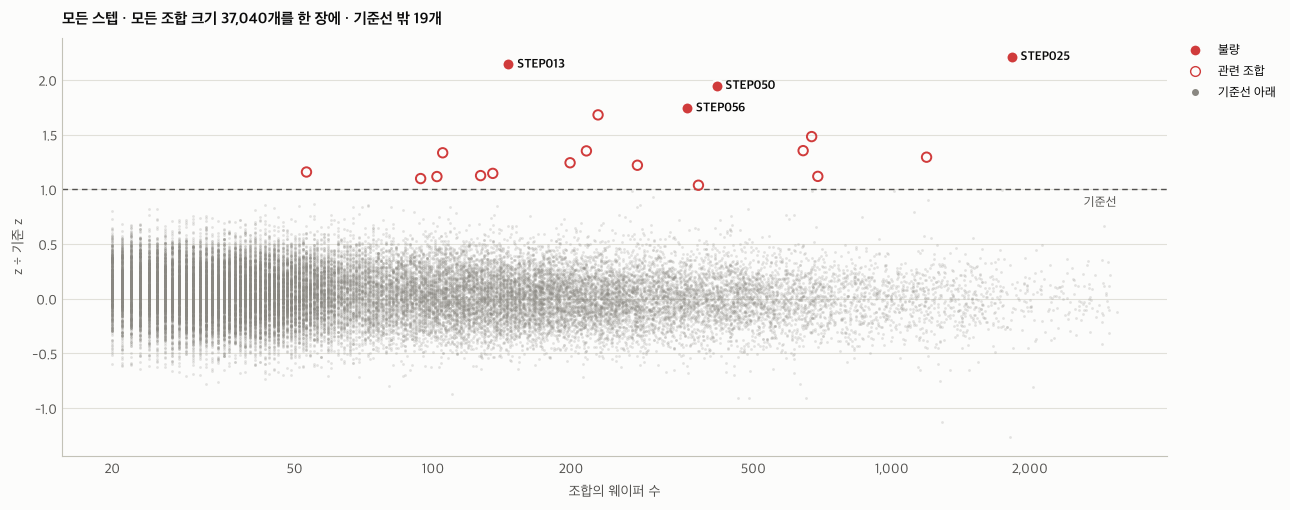

영향 (웨이퍼 × %p) 1위 STEP025 · z ÷ 기준 z 1위 STEP025 · 차이(%p) 1위 STEP013


,스텝,공정,경로,오더 수,웨이퍼,차이(%p),z ÷ 기준 z,영향 (웨이퍼 × %p),연결된 점,key
순위 (영향 (웨이퍼 × %p)),,,,,,,,,,
1,STEP025,CLN,O1:CLN18,1,1826,0.1079,2.213,196.9,3,24|0:0
2,STEP050,DIF,O2:DIF30 → O3:DIF17,2,415,0.2315,1.948,96.06,3,49|1:0|2:1
3,STEP056,DIF,O1:DIF58 → O3:DIF11,2,358,0.223,1.743,79.85,2,55|0:2|2:3
4,STEP013,IMP,O4:IMP18 → O5:IMP02 → O8:IMP11,3,146,0.4556,2.143,66.52,11,12|3:3|4:0|7:1


In [29]:
over_pts = [c for c in res['combos'] if c['over'] and in_scope(c)]
by_target = defaultdict(list)
for c in over_pts:
    t = representative(res, zk, c)
    by_target[t['key'] if t else None].append(c)
n_shown = sum(in_scope(c) for c in res['combos'])
print(f"기준선 밖의 점 {len(over_pts)}개 → 대표 불량 대상 {sum(k is not None for k in by_target)}개"
      + (f" · 확정 불량 없음 {len(by_target[None])}개" if None in by_target else ''))
fig, ax = plt.subplots(figsize=(13, 5.2))
plot_unified(ax, data, res, zk, title=f'모든 스텝 · 모든 조합 크기 {n_shown:,}개를 한 장에 · 기준선 밖 {len(over_pts)}개')
plt.tight_layout()
plt.show()

rep_rows = []
for key, pts in by_target.items():
    if key is not None:
        c = res['by_key'][key]
        rep_rows.append({**combo_row(res, zk, steps[c['step']], c), '연결된 점': len(pts), 'key': key})
rep_df = pd.DataFrame(rep_rows).sort_values(RANK_COL[RANK], ascending=False)
rep_df.index = pd.RangeIndex(1, len(rep_df) + 1, name=f'순위 ({RANK_COL[RANK]})')
print(' · '.join(f"{RANK_COL[k]} 1위 {rep_df.sort_values(col, ascending=False).iloc[0]['스텝']}" for k, col in RANK_COL.items()))
display(rep_df)

**점을 골랐을 때**: 1위 대표 대상의 후보 중 기준선을 겨우 넘은 관련 조합을 고른 예입니다(`PICK`으로 바꿀 수 있음). 후보 표의 '판정'이 각 후보가 대표가 아닌 이유입니다.

고른 점: STEP025 · O1:CLN18 → O2:CLN15 (관련 조합 · 상속)
대표 불량 대상: STEP025 · O1:CLN18


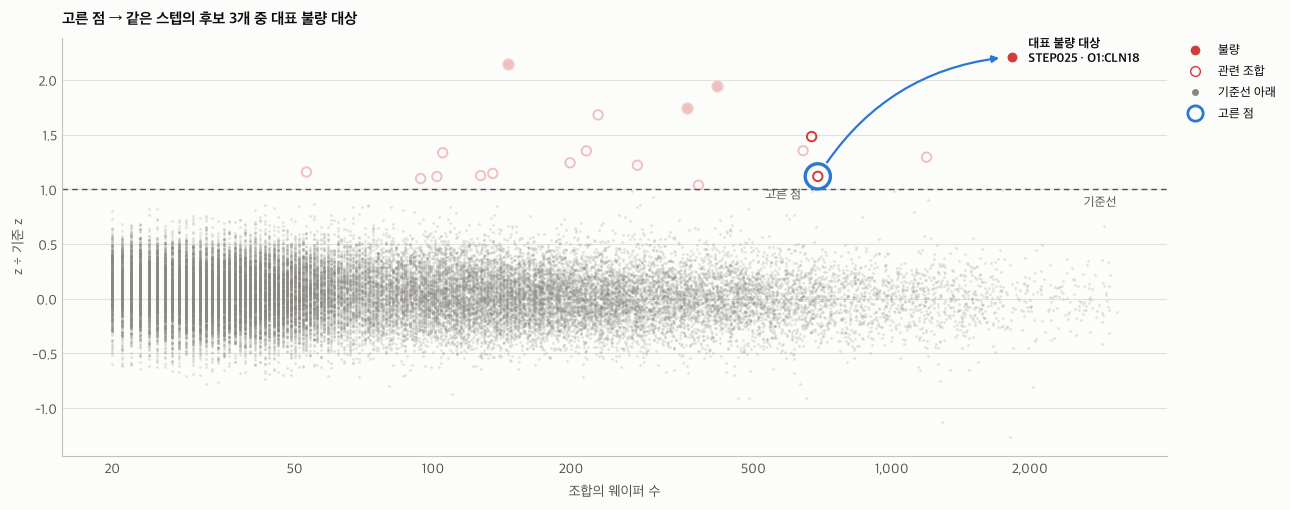

,경로,오더 수,웨이퍼,차이(%p),z ÷ 기준 z,영향 (웨이퍼 × %p),판정
후보,,,,,,,
1,O1:CLN18,1,1826,0.1079,2.213,196.9,대표 불량 대상
2,O1:CLN18 → O2:CLN16,2,669,0.1387,1.482,92.78,상속: O1:CLN18 대비 t 1.9 ≤ 기준 4.6
3,O1:CLN18 → O2:CLN15,2,690,0.1031,1.118,71.11,상속: O1:CLN18 대비 t -0.3 ≤ 기준 4.6


In [30]:
if PICK:
    pick = res['by_key'][PICK]
else:
    top = res['by_key'][rep_df.iloc[0]['key']]
    rel = [b for b in candidates(res, top) if b['status'] != 'bad']
    pick = min(rel, key=lambda b: b['z'] / zk[b['k']]) if rel else top
target, cand_df = candidate_table(data, res, zk, pick)
st = steps[pick['step']]
print(f"고른 점: {st['name']} · {path_label(st, pick['items'])} ({STATUS_LABEL[pick['status']]})")
print('대표 불량 대상: ' + (f"{st['name']} · {path_label(st, target['items'])}" if target else '확정 불량 없음'))
fig, ax = plt.subplots(figsize=(13, 5.2))
plot_unified(ax, data, res, zk, pick=pick, title=f"고른 점 → 같은 스텝의 후보 {len(cand_df)}개 중 대표 불량 대상")
plt.tight_layout()
plt.show()
display(cand_df)

### 8-2. 여러 시드에서 점검
기준선 밖의 점이 모두 올바른 대표 대상으로 연결되는지, 한 차트에 남는 후보가 몇 개인지 봅니다. 아래 8-3의 스텝 간 규칙이 정상 데이터에서 심어 둔 불량을 다른 스텝 탓으로 잘못 돌리지 않는지도 함께 봅니다.

In [31]:
def cross_step_check(d, r, zk_):
    """스텝 간 규칙: 다른 스텝의 불량 조합 A와 웨이퍼가 겹치는 불량 조합 B에 대해, A를 지나지 않은 웨이퍼만 놓고
    B가 나머지보다 높은지(Welch t) 본다. B의 효과가 사라지고(t ≤ 1.96) A는 B 없이도 기준을 넘으면 B를 'A 기인'으로 본다.
    전체 평균에는 A의 불량이 섞여 있어서 비교 기준은 'A를 지나지 않은 웨이퍼'로 두고, 웨이퍼가 줄어든 만큼 진짜 불량도
    보정 기준 아래로 떨어질 수 있어서 B 쪽은 '효과가 남아 있는가'(1.96)만 본다"""
    bads = [c for c in r['combos'] if c['status'] == 'bad']
    mem = {c['key']: members_of(d, c) for c in bads}
    y, y2 = d['Y'], d['Y'] ** 2

    def t_without(c, other):
        a, b = mem[c['key']] & ~mem[other['key']], ~mem[c['key']] & ~mem[other['key']]
        return float(welch(a.sum(), y[a].sum(), y2[a].sum(), b.sum(), y[b].sum(), y2[b].sum())[0][0])

    out = {}
    for b in bads:
        cause = [(t_without(b, a), a) for a in bads if a['step'] != b['step'] and (mem[a['key']] & mem[b['key']]).any()]
        cause = [(t, a) for t, a in cause if t <= Z95 and t_without(a, b) > zk_[a['k']]]
        if cause:
            out[b['key']] = min(cause, key=lambda ta: ta[0])[1]      # B를 가장 많이 설명하는 A
    return out


t0 = time.perf_counter()
link_tally = {'정답으로 연결': 0, '다른 조합으로 연결': 0, '확정 불량 없음': 0}
noise_tally = {'불량으로 연결': 0, '확정 불량 없음': 0}
n_reps, wrong_cross = [], 0
for sd_ in CHECK_SEEDS:
    d, r, z = run_seed(sd_)
    truth = {e['step']: combo_key(e['step'], tuple(sorted(e['items']))) for e in d['effects']}
    reps = set()
    for c in (c for c in r['combos'] if c['over']):
        t = representative(r, z, c)
        if t:
            reps.add(t['key'])
        if e := shared_effect(d, c):
            link_tally['확정 불량 없음' if t is None else '정답으로 연결' if t['key'] == truth[e['step']] else '다른 조합으로 연결'] += 1
        else:
            noise_tally['확정 불량 없음' if t is None else '불량으로 연결'] += 1
    n_reps.append(len(reps))
    wrong_cross += sum(k in truth.values() for k in cross_step_check(d, r, z))
print(f'시드 {len(n_reps)}개 · {time.perf_counter() - t0:.0f}초')
print(f'심어 둔 불량과 관련된 기준선 밖 점 {sum(link_tally.values())}개: {link_tally}')
print(f'우연히 튄 점 {sum(noise_tally.values())}개: {noise_tally}')
print(f'한 차트의 대표 불량 대상 수: 시드별 {min(n_reps)}~{max(n_reps)}개 (심어 둔 불량 4개)')
print(f'스텝 간 규칙이 심어 둔 불량을 다른 스텝 탓으로 돌린 경우: {wrong_cross}건')

시드 20개 · 25초
심어 둔 불량과 관련된 기준선 밖 점 277개: {'정답으로 연결': 276, '다른 조합으로 연결': 0, '확정 불량 없음': 1}
우연히 튄 점 4개: {'불량으로 연결': 1, '확정 불량 없음': 3}
한 차트의 대표 불량 대상 수: 시드별 3~5개 (심어 둔 불량 4개)
스텝 간 규칙이 심어 둔 불량을 다른 스텝 탓으로 돌린 경우: 0건


### 8-3. 여러 스텝이 얽힐 때 ① 스텝 간 설비 연관
현재 프로세스는 스텝마다 따로 판정합니다. 그런데 실제 라인에서는 두 스텝의 설비가 짝지어 운영되기도 합니다. 예를 들어 A 스텝의 유닛 U를 지난 웨이퍼가 B 스텝의 유닛 V로 몰리는 경우입니다. 그러면 A의 불량이 B의 V에도 그대로 묻어 나와, 한 차트에 **원인이 하나인데 후보가 둘**로 보입니다.

아래는 단일 유닛 불량(+0.3%p)을 심은 스텝의 웨이퍼 80%를 다른 스텝의 한 유닛으로 보낸 경우입니다. 불량은 원래 스텝에만 있습니다.

**스텝 간 규칙**: 불량 조합 B가 다른 스텝의 불량 조합 A와 웨이퍼가 겹치면, A를 지나지 않은 웨이퍼만 놓고 B가 나머지보다 높은지(Welch t) 봅니다. B의 효과가 사라지고(t ≤ 1.96) A는 B 없이도 기준을 넘으면, B를 'A 기인'(다른 스텝 기인)으로 봅니다.

스텝 안의 '하위 기인'과 같은 생각을 스텝 사이로 넓힌 것입니다. 두 가지를 조심했습니다.
- 비교 기준을 전체 평균이 아니라 'A를 지나지 않은 웨이퍼'로 둡니다. 전체 평균에는 A의 불량이 섞여 있어서, 그대로 비교하면 독립된 진짜 불량까지 A 탓으로 돌립니다.
- B 쪽은 보정 기준이 아니라 '효과가 남아 있는가'(1.96)만 봅니다. A의 웨이퍼를 빼면 표본이 줄어서, 진짜 불량도 보정 기준 아래로 떨어질 수 있습니다.

불량: STEP025 · O1:CLN18 (+0.3%p) → 웨이퍼 80%를 STEP001 · O1:DIF48로 보냄


,스텝,공정,경로,오더 수,웨이퍼,차이(%p),z ÷ 기준 z,영향 (웨이퍼 × %p),현재 판정,스텝 간 규칙
후보,,,,,,,,,,
1,STEP025,CLN,O1:CLN18,1,1826,0.2031,4.041,370.8,불량,불량 유지
2,STEP001,DIF,O1:DIF48,1,2705,0.05614,1.36,151.8,불량,다른 스텝 기인 (STEP025 O1:CLN18)
3,STEP050,DIF,O2:DIF30 → O3:DIF17,2,415,0.236,1.926,97.92,불량,불량 유지
4,STEP056,DIF,O1:DIF58 → O3:DIF11,2,358,0.2265,1.718,81.09,불량,불량 유지
5,STEP013,IMP,O4:IMP18 → O5:IMP02 → O8:IMP11,3,146,0.4594,2.096,67.07,불량,불량 유지


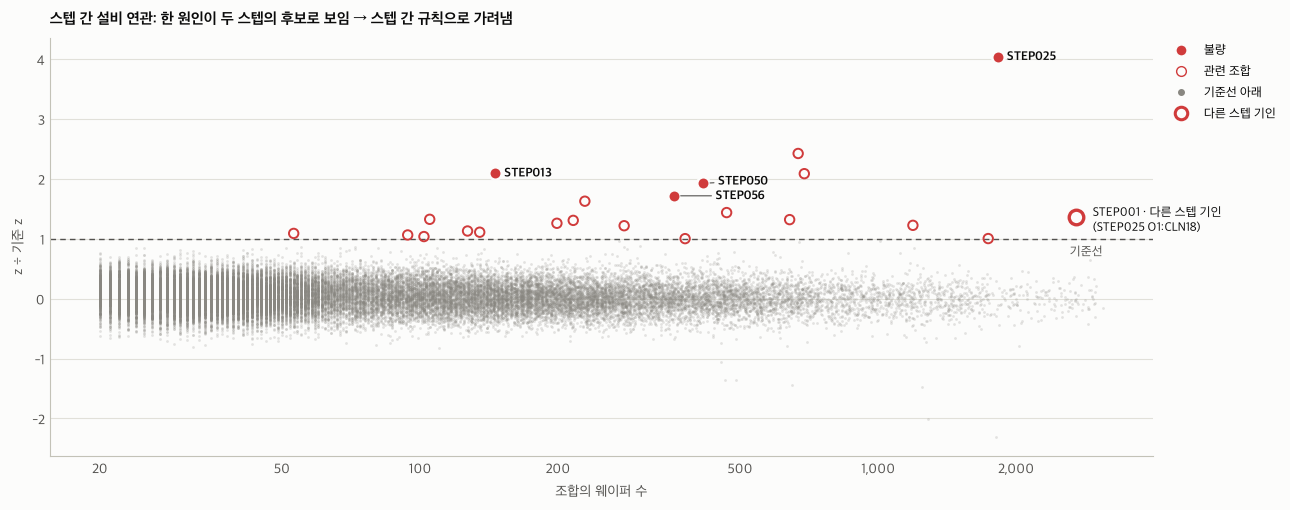

시드 10개 · 12초 · {'가짜 후보가 불량으로 뜸': 10, '그중 원래 스텝으로 연결': 10, '심어 둔 불량을 잘못 돌림': 0}


In [32]:
LINK = 0.8


def link_routing(d, src, dst, link=LINK, seed=0):
    """src(스텝, 오더, 유닛)를 지난 웨이퍼의 link 비율을 dst(스텝, 오더, 유닛)로 보낸다. Y는 그대로(불량은 src에만)"""
    (ss, sq, su), (ds, dq, du) = src, dst
    move = (d['assign'][ss][sq] == su) & (np.random.default_rng(seed).random(d['N']) < link) & (d['assign'][ds][dq] != MISSING)
    A = list(d['assign'])
    A[ds] = A[ds].copy()
    A[ds][dq, move] = du
    return {**d, 'assign': A}


def link_setup(seed):
    """단일 유닛 불량(+0.3%p)을 심은 스텝 → 불량과 무관한 스텝 중 유닛이 3개 이상인 첫 오더의 첫 유닛으로 경로 연관"""
    base = generate(seed, effects={'single': 0.3})
    e1 = next(e for e in base['effects'] if e['type'] == 'single')
    src = (e1['step'], *e1['items'][0])
    eff_steps = {e['step'] for e in base['effects']}
    ds = next(s for s, st_ in enumerate(base['steps']) if s not in eff_steps and not st_['decoy'] and any(len(q['units']) >= 3 for q in st_['seqs']))
    dq = next(q for q, sq in enumerate(base['steps'][ds]['seqs']) if len(sq['units']) >= 3)
    return link_routing(base, src, (ds, dq, 0)), src, (ds, dq, 0)


linked, src, (ds, dq, _) = link_setup(SEED)
rl = analyze(linked, min_n=MIN_N)
zl = thresholds(rl, 'bonf')
classify(rl, zl)
cross = cross_step_check(linked, rl, zl)
S_, D_ = linked['steps'][src[0]], linked['steps'][ds]
print(f"불량: {S_['name']} · {S_['seqs'][src[1]]['name']}:{S_['seqs'][src[1]]['units'][src[2]]} (+0.3%p) → "
      f"웨이퍼 {LINK:.0%}를 {D_['name']} · {D_['seqs'][dq]['name']}:{D_['seqs'][dq]['units'][0]}로 보냄")
link_rows = []
for c in sorted((c for c in rl['combos'] if c['status'] == 'bad'), key=lambda c: -metric(c, rl, zl)):
    st_ = linked['steps'][c['step']]
    a = cross.get(c['key'])
    link_rows.append({**combo_row(rl, zl, st_, c), '현재 판정': '불량',
                      '스텝 간 규칙': f"다른 스텝 기인 ({linked['steps'][a['step']]['name']} {path_label(linked['steps'][a['step']], a['items'])})" if a else '불량 유지'})
display(pd.DataFrame(link_rows, index=pd.RangeIndex(1, len(link_rows) + 1, name='후보')))
fig, ax = plt.subplots(figsize=(13, 5.2))
plot_unified(ax, linked, rl, zl, cross=cross, title='스텝 간 설비 연관: 한 원인이 두 스텝의 후보로 보임 → 스텝 간 규칙으로 가려냄')
plt.tight_layout()
plt.show()

# 여러 시드: 옮겨 받은 가짜 후보가 불량으로 뜨는지, 스텝 간 규칙이 원래 스텝으로 돌리는지
t0 = time.perf_counter()
link_stats = {'가짜 후보가 불량으로 뜸': 0, '그중 원래 스텝으로 연결': 0, '심어 둔 불량을 잘못 돌림': 0}
link_seeds = list(CHECK_SEEDS)[:10]
for sd_ in link_seeds:
    lk, (ss_, sq_, su_), (ds_, dq_, du_) = link_setup(sd_)
    r_ = analyze(lk, min_n=MIN_N)
    z_ = thresholds(r_, 'bonf')
    classify(r_, z_)
    cr = cross_step_check(lk, r_, z_)
    fake = combo_key(ds_, ((dq_, du_),))
    if r_['by_key'].get(fake, {}).get('status') == 'bad':
        link_stats['가짜 후보가 불량으로 뜸'] += 1
        link_stats['그중 원래 스텝으로 연결'] += fake in cr and cr[fake]['key'] == combo_key(ss_, ((sq_, su_),))
    link_stats['심어 둔 불량을 잘못 돌림'] += sum(k in truth_keys(lk) for k in cr)
print(f'시드 {len(link_seeds)}개 · {time.perf_counter() - t0:.0f}초 · {link_stats}')

### 8-4. 여러 스텝이 얽힐 때 ② 랏 단위 상관
7-3(c)에서 본 것처럼, 한 랏이 같은 유닛을 지나고 랏마다 수준이 다르면 불량이 없어도 수천 개가 기준선을 넘습니다. 그러면 한 차트가 점으로 뒤덮여 소수의 후보를 볼 수 없습니다.

원인은 기준선이 웨이퍼를 서로 독립인 표본으로 보는 데 있습니다. **랏을 통째로 섞는 순열**로 기준선을 만들면 랏 안의 상관이 그대로 반영됩니다. 웹의 순열 검정은 웨이퍼 단위로 섞으므로 이 문제를 풀지 못합니다.

32초


시드                                              1                                                          2                                        
데이터                                         불량 없음               불량 심음               불량 3배              불량 없음               불량 심음               불량 3배
웨이퍼 기준 (현재) · 기준 z (오더 1/2/3개)    4.0 / 4.6 / 5.0     4.0 / 4.6 / 5.0     4.0 / 4.6 / 5.0    4.0 / 4.6 / 5.0     4.0 / 4.6 / 5.0     4.0 / 4.6 / 5.0
웨이퍼 기준 (현재) · 불량 판정                          1952                2354                6611               1690                2014                6556
웨이퍼 기준 (현재) · 심어 둔 불량 탐지                        –                 2/4                 4/4                  –                 2/4                 4/4
랏 순열 기준 · 기준 z (오더 1/2/3개)      9.8 / 12.3 / 12.0  10.3 / 13.1 / 13.2  13.8 / 17.4 / 16.8  9.5 / 10.5 / 10.4  10.3 / 11.3 / 11.5  13.5 / 16.3 / 16.5
랏 순열 기준 · 불량 판정                                 0                   0                   4                  0                   1                   2
랏 순열 기준 · 심어 둔 불량 탐지                            –                 0/4                 4/4                  –                 0/4                 2/4

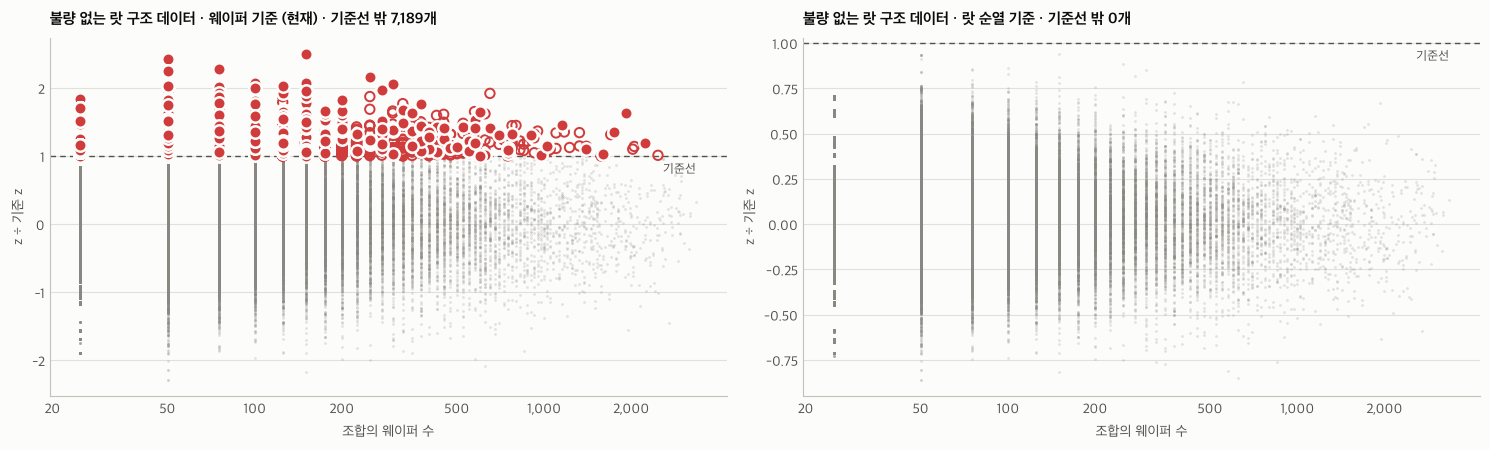

In [33]:
def perm_envelope_lot(d, r, n_perm=N_PERM, alpha=FWER_ALPHA, seed=SEED):
    """랏 단위 순열: 랏(웨이퍼 25장)을 통째로 섞어 랏 안의 상관을 유지한 채 깊이별 최대 z의 (1−α) 분위수를 구한다"""
    members = build_members(d, r)
    lens = np.array([len(m) for m in members])
    offsets = np.concatenate([[0], np.cumsum(lens)[:-1]])
    flat = np.concatenate(members)
    depth = np.array([c['k'] for c in r['combos']])
    masks = {k: depth == k for k in range(1, r['max_depth'] + 1)}
    yl = d['Y'].reshape(-1, d['cfg']['waferPerLot'])
    inv_se = np.sqrt(lens) / r['sd']
    rng = np.random.default_rng(seed)
    max_z = {k: [] for k in masks}
    for _ in range(n_perm):
        yp = yl[rng.permutation(len(yl))].ravel()
        z = (np.add.reduceat(yp[flat], offsets) / lens - r['mu']) * inv_se
        for k, m in masks.items():
            if m.any():
                max_z[k].append(z[m].max())
    return [0.0] + [quantile(np.sort(max_z[k]), 1 - alpha) if max_z[k] else None for k in masks]


def lot_scenario(seed, lot_sd=0.3, scale=1.0):
    """랏 단위 배정(랏 첫 웨이퍼의 유닛을 랏 전체에) + 랏 간 편차. 불량은 바뀐 배정 기준으로 scale배 크기로 다시 심는다"""
    d = generate(seed, **NO_EFFECT)
    wpl, n = d['cfg']['waferPerLot'], d['N']
    lots = np.arange(n) // wpl
    assign = [a[:, lots * wpl] for a in d['assign']]
    y = d['Y'] + lot_sd * np.random.default_rng(seed).normal(size=n // wpl)[lots]
    for e in d['effects'] if scale else []:
        y[np.all([assign[e['step']][q] == u for q, u in e['items']], axis=0)] += scale * DEFAULTS['effects'][e['type']]
    return {**d, 'assign': assign, 'Y': np.maximum(0, y)}


LOT_DATA = {'불량 없음': 0.0, '불량 심음': 1.0, '불량 3배': 3.0}
t0 = time.perf_counter()
lot_rows, lot_plot = [], []
for sd_ in list(LOT_SEEDS)[:2]:
    for label, scale in LOT_DATA.items():
        d = lot_scenario(sd_, scale=scale)
        r = analyze(d, min_n=MIN_N)
        tk = truth_keys(d) if scale else set()
        row_ = {'시드': sd_, '데이터': label}
        for name, zz in (('웨이퍼 기준 (현재)', thresholds(r, 'bonf')), ('랏 순열 기준', thresholds(r, 'perm', perm_envelope_lot(d, r, seed=sd_)))):
            classify(r, zz)
            keys = {c['key'] for c in r['combos'] if c['status'] == 'bad'}
            row_[f'{name} · 기준 z (오더 1/2/3개)'] = ' / '.join(f'{v:.1f}' for v in zz[1:])
            row_[f'{name} · 불량 판정'] = len(keys)
            row_[f'{name} · 심어 둔 불량 탐지'] = f'{len(keys & tk)}/4' if scale else '–'
            if sd_ == list(LOT_SEEDS)[0] and not scale:
                lot_plot.append((name, d, r, zz, [dict(c) for c in r['combos']]))
        lot_rows.append(row_)
print(f'{time.perf_counter() - t0:.0f}초')
display(pd.DataFrame(lot_rows).set_index(['시드', '데이터']).T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), sharey=False)
for ax, (name, d, r, zz, snap) in zip(axes, lot_plot):
    r_view = {**r, 'combos': snap}
    plot_unified(ax, d, r_view, zz, title=f'불량 없는 랏 구조 데이터 · {name} · 기준선 밖 {sum(c["over"] for c in snap):,}개')
    ax.get_legend().remove()
plt.tight_layout()
plt.show()

### 8-5. 요약: 여러 스텝을 한 차트로 볼 때 현재 프로세스로 충분한가

In [34]:
lot_df8 = pd.DataFrame(lot_rows)
null8 = lot_df8[lot_df8['데이터'] == '불량 없음']


def lot_hits(label, col):
    rows_ = lot_df8[lot_df8['데이터'] == label]
    return f"{sum(int(s.split('/')[0]) for s in rows_[col])}/{4 * len(rows_)}"


W, L = '웨이퍼 기준 (현재)', '랏 순열 기준'
lines8 = [
    f"독립 경로(mock): 한 차트의 대표 불량 대상 시드별 {min(n_reps)}~{max(n_reps)}개 · 기준선 밖 점 {sum(link_tally.values())}개 중 "
    f"{link_tally['정답으로 연결']}개가 정답으로 연결, 다른 조합으로 연결 {link_tally['다른 조합으로 연결']}개 → 충분",
    f"스텝 간 설비 연관: 시드 {len(link_seeds)}개 중 {link_stats['가짜 후보가 불량으로 뜸']}개에서 다른 스텝의 불량을 옮겨 받은 가짜 후보가 불량으로 뜸 → "
    f"스텝 간 규칙이 {link_stats['그중 원래 스텝으로 연결']}개를 원래 스텝으로 연결 (심어 둔 불량을 잘못 돌린 경우: 연관 {link_stats['심어 둔 불량을 잘못 돌림']}건, "
    f"정상 {wrong_cross}건)",
    f"랏 단위 상관: 불량 없는 데이터의 불량 판정 {W} 평균 {null8[f'{W} · 불량 판정'].mean():.0f}개 → {L} {null8[f'{L} · 불량 판정'].mean():.0f}개 · "
    f"심어 둔 불량 탐지 {lot_hits('불량 심음', f'{W} · 심어 둔 불량 탐지')} → {lot_hits('불량 심음', f'{L} · 심어 둔 불량 탐지')}, "
    f"3배 불량 {lot_hits('불량 3배', f'{W} · 심어 둔 불량 탐지')} → {lot_hits('불량 3배', f'{L} · 심어 둔 불량 탐지')} → 랏 단위 기준선 필요, 대신 작은 불량은 놓침",
    f"'가장 불량한' 기준: 영향 · 증거 · 심각도에 따라 1위가 달라질 수 있음 → 기본값을 정해야 함 (지금 {RANK_COL[RANK]})",
]
print('\n'.join(f'• {l}' for l in lines8))

• 독립 경로(mock): 한 차트의 대표 불량 대상 시드별 3~5개 · 기준선 밖 점 277개 중 276개가 정답으로 연결, 다른 조합으로 연결 0개 → 충분
• 스텝 간 설비 연관: 시드 10개 중 10개에서 다른 스텝의 불량을 옮겨 받은 가짜 후보가 불량으로 뜸 → 스텝 간 규칙이 10개를 원래 스텝으로 연결 (심어 둔 불량을 잘못 돌린 경우: 연관 0건, 정상 0건)
• 랏 단위 상관: 불량 없는 데이터의 불량 판정 웨이퍼 기준 (현재) 평균 1821개 → 랏 순열 기준 0개 · 심어 둔 불량 탐지 4/8 → 0/8, 3배 불량 8/8 → 6/8 → 랏 단위 기준선 필요, 대신 작은 불량은 놓침
• '가장 불량한' 기준: 영향 · 증거 · 심각도에 따라 1위가 달라질 수 있음 → 기본값을 정해야 함 (지금 영향 (웨이퍼 × %p))
